# Analysis of phasic and tonic zinc response in 2-photon

## Broadband train (preZX1)

In [ ]:
import lib.signalProcess as signalProcess
import numpy as np

# WT
resp2pPaths = [
    # w/ 0dB control, only preZX1
    r"C:\Data\Shengjie Data\TLB10-GRISZ\11252025\AA0001\Broadband_20_80dB_400msStimLength_13trials\AA0001\GRISZ_20251125_BB_CTRL_rawFluoWholeTraces.mat", 
    r"C:\Data\Shengjie Data\TLB10-GRISZ\11262025\AA0001\Broadband_20_80dB_400msStimLength_14trials\AA0001\GRISZ_20251126_BB_CTRL_rawFluoWholeTraces.mat", 
    r"C:\Data\Shengjie Data\TLB10-GRISZ\20260129\AA0001\GRISZ\AA0001\GRISZ_20260129_BB_CTRL_rawFluoWholeTraces.mat", 
    r"C:\Data\Shengjie Data\TLB10-GRISZ\20260213\AA0001\AA0001\GRISZ_20260213_BB_CTRL_rawFluoWholeTraces.mat", 
    r"C:\Data\Shengjie Data\TLB10-GRISZ\20260216\AA0001\AA0001\GRISZ_20260216_BB_CTRL_rawFluoWholeTraces.mat",

    # w/ 0dB control. preZX1 and postZX1 
    r"C:\Data\Shengjie Data\TLB10-GRISZ\20260406\AA0001\AA0001\GRISZ_20260406_BB_preZX1_rawFluoWholeTraces.mat", 
    r"C:\Data\Shengjie Data\TLB10-GRISZ\20260407\AA0001\AA0001\GRISZ_20260407_BB_preZX1_rawFluoWholeTraces.mat", 
    r"C:\Data\Shengjie Data\TLB10-GRISZ\20260413\preZX1\AA0001\GRISZ_20260413_BB_preZX1_rawFluoWholeTraces.mat", 
    r"C:\Data\Shengjie Data\TLB10-GRISZ\20260414\AA0001\AA0001\GRISZ_20260414_BB_preZX1_rawFluoWholeTraces.mat"
]

# ZnT3 KO (globally)
# resp2pPaths = [
#     r"C:\Data\Shengjie Data\TLB10-GRISZ\04072025\AA0001\Control_2photon_broadband_14trains_MKprotocol\AA0001\GRISZ_20250407_BB_CTRL_rawFluoWholeTraces.mat", 
#     r"C:\Data\Shengjie Data\TLB10-GRISZ\20260303\AA0001\AA0001\GRISZ_20260303_BB_CTRL_rawFluoWholeTraces.mat"
# ]

# ZnT3 Cre/ROX (conditionally ZnT3 KO), preZX1 and postZX1
# resp2pPaths = [
#     r"C:\Data\Shengjie Data\TLB10-GRISZ\20260316\AA0001\AA0001\GRISZ_20260316_BB_preZX1_rawFluoWholeTraces.mat", 
#     r"C:\Data\Shengjie Data\TLB10-GRISZ\20260318\AA0001\AA0001\GRISZ_20260318_BB_preZX1_rawFluoWholeTraces.mat", 
#     r"C:\Data\Shengjie Data\TLB10-GRISZ\20260323\AA0001\AA0001\GRISZ_20260323_BB_preZX1_rawFluoWholeTraces.mat"
# ]

t_base = (-1, 0)  # Specify baseline window relative to sound onset
t_resp_phasic = (0.3, 1.3)  # Specify response (phasic) window relative to sound onset
t_resp_tonic = (2, 3.9)  # Specify response (tonic) window relative to sound onset

# Extract metadata and aligned raw F traces
levelOrder, soundOnsets, timeVector, rawWholeTraces_list = signalProcess.align2pRawTraces(resp2pPaths, alignMethod='pad', lowpassFreq=2, add0dB=True)

# rawWholeTraces_list_processed = rawWholeTraces_list
# Process raw F traces by excluding negative trace segments
rawWholeTraces_list_processed = signalProcess.process_2pRawTraces(
    rawWholeTraces_list, timeVector, soundOnsets, t_base=t_base, t_resp_phasic=t_resp_phasic, t_resp_tonic=t_resp_tonic)

Extracted raw whole fluorescence traces [traceNumber, neuronNumber, frame] of shape: (7, 99, 260)
Extracted raw whole fluorescence traces [traceNumber, neuronNumber, frame] of shape: (11, 87, 260)
Extracted raw whole fluorescence traces [traceNumber, neuronNumber, frame] of shape: (6, 130, 260)
Extracted raw whole fluorescence traces [traceNumber, neuronNumber, frame] of shape: (11, 146, 260)


In [44]:
soundOnsets

array([ 6.19008, 11.18208, 16.37376, 21.36576, 26.55744, 31.54944,
       36.74112, 41.73312])

In [ ]:
# temp = rawWholeTraces_list_processed[0][2, :, :][np.newaxis, :, :]
# temp = np.delete(rawWholeTraces_list_processed[0], [3, 10, 11], axis=0)
# rawWholeTraces_list_processed = []
# rawWholeTraces_list_processed.append(temp)

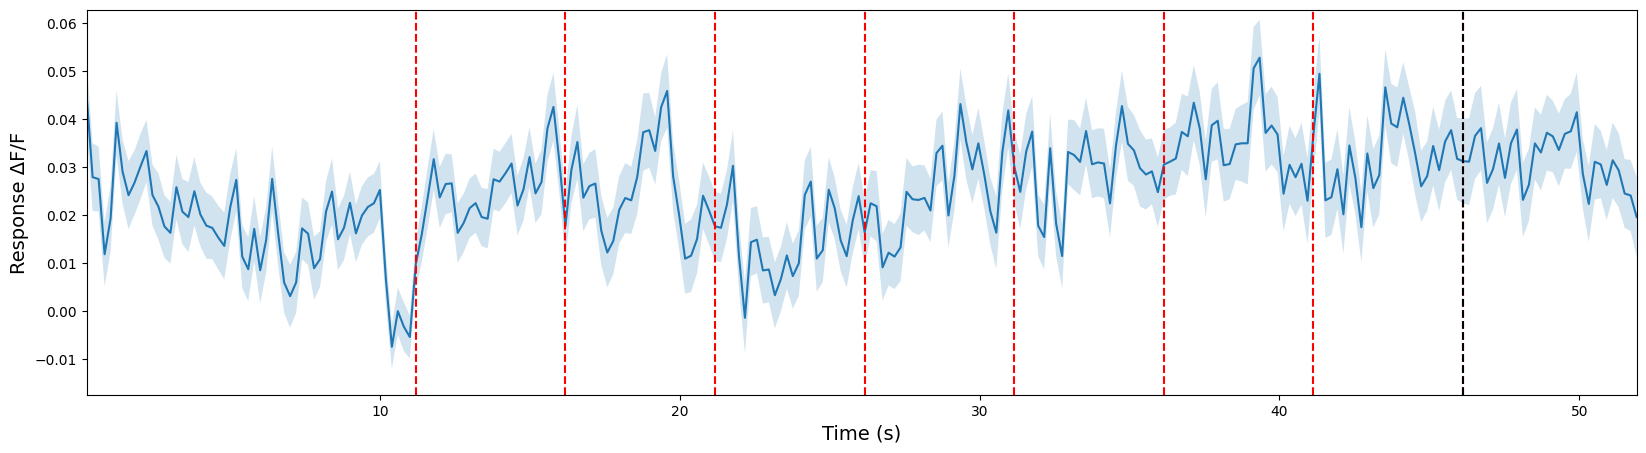

In [19]:
# Preview whole traces with specified baseline
import matplotlib.pyplot as plt

# Find the closest time point to first sound onset - 5s as prepend stimulus to reduce adaptation effect
soundOnset_prepend = timeVector[np.argmin(np.abs(timeVector - (soundOnsets[0] - np.mean(np.diff(soundOnsets)))))]

soundOnset_selected = soundOnsets[0]
# soundOnset_selected = soundOnsets[-1]  # 0 dB control
# soundOnset_selected = soundOnset_prepend

dFFwholeTraces_list = signalProcess.compute_2pDFFtraces(rawWholeTraces_list_processed, timeVector, soundOnset_selected, t_base=t_base, t_resp=t_resp_phasic)
dFFwholeTraces_trialAvg = np.concatenate(
    [np.nanmean(dFFwholeTrace, axis=0) for dFFwholeTrace in dFFwholeTraces_list], 
    axis=0
)

# Average traces across all neurons
avg_traces, traces_psem, traces_msem = signalProcess.meanPlusMinusSem(dFFwholeTraces_trialAvg, ignoreNaN=True)  # Handle NaNs if any
ymin, ymax = np.nanmin(avg_traces) - 0.01, np.nanmax(avg_traces) + 0.01

fig, ax = plt.subplots(figsize=(20, 5))
# for i in range(dFFwholeTraces_trialAvg.shape[0]):
#     ax.plot(timeVector, dFFwholeTraces_trialAvg[i, :], color='gray', alpha=0.02)
ax.plot(timeVector, avg_traces)
ax.fill_between(timeVector, traces_psem, traces_msem, alpha=0.2)
for soundOnset in soundOnsets:
    ax.axvline(x=soundOnset, color='red', linestyle='--')
ax.set_xlabel('Time (s)', fontsize=14)
ax.set_ylabel('Response ΔF/F', fontsize=14)
ax.set_xlim(timeVector[0], timeVector[-1])
ax.set_ylim(ymin, ymax)
ax.axvline(x=soundOnsets[-1], color='k', linestyle='--')  # 0 dB control
# ax.axvline(x=soundOnset_prepend, color='orange', linestyle='--')

plt.show()

In [20]:
# Initialize a dict mapping sound levels to their corresponding dF/F trace segments (from soundOnset-1 to soundOnset+4)
import pandas as pd
dB2trace = {}

for i in range(len(levelOrder)):
    dFFwholeTraces_list = signalProcess.compute_2pDFFtraces(rawWholeTraces_list_processed, timeVector, soundOnsets[i], t_base=t_base, t_resp=t_resp_phasic)
    dFFwholeTraces_trialAvg = np.concatenate(
        [np.nanmean(dFFwholeTrace, axis=0) for dFFwholeTrace in dFFwholeTraces_list], 
        axis=0
    )
    windowInd = np.where((timeVector >= soundOnsets[i] + t_base[0]) & (timeVector <= soundOnsets[i] + t_resp_tonic[1]))[0]
    dB2trace[levelOrder[i]] = dFFwholeTraces_trialAvg[:, windowInd]

# Store dF/F traces across sound levels and neuron indices in a DataFrame
df_resp = pd.DataFrame([
    {'dB': dB, 'neuronIDX': i, 'dFF_trace': arr[i, :]}
    for dB, arr in dB2trace.items()
    for i in range(arr.shape[0])
])
df_resp

,dB,neuronIDX,dFF_trace
0,30,0,"[0.08649695938444905, -0.014417340014952693, 0..."
1,30,1,"[0.17245531592122706, 0.010847784113147458, -0..."
2,30,2,"[-0.043713091161666565, -0.03953539798910886, ..."
3,30,3,"[0.22343265629022024, 0.06336698621377483, -0...."
4,30,4,"[0.18972840420824327, -0.11298519764966866, -0..."
...,...,...,...
3691,0,457,"[-0.07215441103807387, 0.024811810025289156, -..."
3692,0,458,"[-0.08877177580926764, -0.11275019944973885, 0..."
3693,0,459,"[0.02394120815508549, -0.010793889576474683, 0..."
3694,0,460,"[-0.025615308461704678, 0.12506416101338075, 0..."


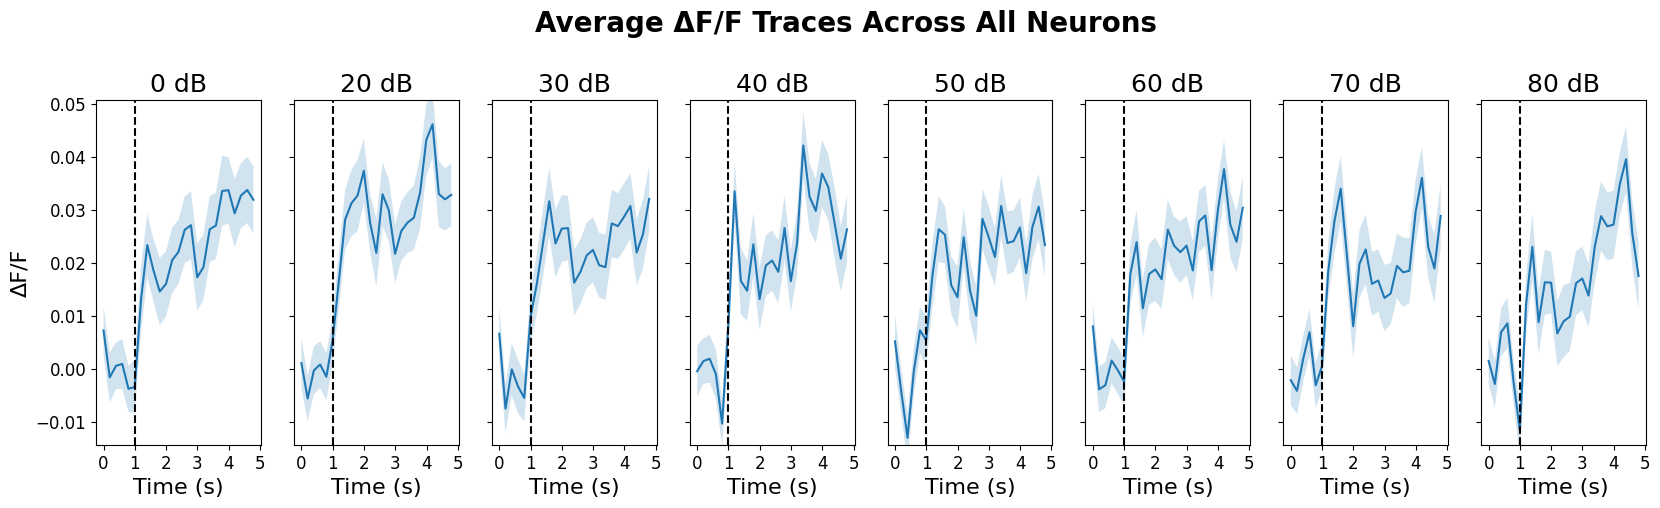

In [21]:
# Plot average dF/F re sound level (all neurons)

# Get unique sound levels
levels = sorted(df_resp['dB'].unique())

# Compute global ymin / ymax across all sound levels
ymins, ymaxs = [], []
for level in levels:
    traces = np.stack(df_resp[df_resp['dB'] == level]['dFF_trace'].values)
    avg_traces, _, _ = signalProcess.meanPlusMinusSem(traces, ignoreNaN=True)
    ymins.append(np.nanmin(avg_traces))
    ymaxs.append(np.nanmax(avg_traces))
ymin, ymax = np.min(ymins) * 1.1, np.max(ymaxs) * 1.1
# ymin, ymax = -0.05, 0.15

# Compute common X axis ticks
trace_len_max = max(len(trace) for trace in df_resp['dFF_trace'])
timeVector_common = np.insert(timeVector[:trace_len_max-1], 0, 0)

fig, ax = plt.subplots(1, len(levels), figsize=(20, 5))
for i, level in enumerate(levels):
    traces = np.stack(df_resp[df_resp['dB'] == level]['dFF_trace'].values)
    avg_traces, traces_psem, traces_msem = signalProcess.meanPlusMinusSem(traces, ignoreNaN=True)  # Handle NaNs if any
    
    # Get time vector within the display window (starting from 0)
    timeVector_seg = np.insert(timeVector[:avg_traces.shape[0]-1], 0, 0)
    
    ax[i].plot(timeVector_seg, avg_traces)
    ax[i].fill_between(timeVector_seg, traces_psem, traces_msem, alpha=0.2)
    ax[i].axvline(x=-t_base[0], color='k', linestyle='--')
    ax[i].set_title(f'{level} dB', fontsize=18)
    ax[i].set_xlabel('Time (s)', fontsize=16)
    ax[i].set_ylim(ymin, ymax)
    ax[i].set_xticks(np.arange(min(timeVector_common), max(timeVector_common) + 1, 1))
    ax[i].tick_params(axis='both', labelsize=12)
    if i == 0:
        ax[i].set_ylabel('ΔF/F', fontsize=16)
    else:
        ax[i].set_yticklabels([])

fig.suptitle('Average ΔF/F Traces Across All Neurons', fontsize=20, fontweight='bold')
fig.subplots_adjust(top=0.8)

plt.show()

In [22]:
# Get indices of responsive neurons (neurons that are responsive at at least two consecutive sound levels)

thres_SD = 2  # Specify criteria threshold
nonSignificant2Zero_phasic = True  # Whether to replace non-significant phasic responses with zeros
nonSignificant2Zero_tonic = False  # Whether to replace non-significant tonic responses with zeros
avgAdjacentFrames = False  # Whether to average peak amplitude with adjacent two frames (±1 frame) to reduce noise

# Initialize new columns in df_resp
df_resp['responsive_level'] = False
df_resp['dFF_peak_phasic'] = np.nan
df_resp['dFF_avg_tonic'] = np.nan

for level in sorted(df_resp['dB'].unique()):  # Including 0 dB
    # Reconstruct traces from df_resp (shape: [neuronNumber, frame])
    mask = df_resp['dB'] == level
    traces = np.stack(df_resp.loc[mask, 'dFF_trace'].values)
    
    # Get time vector within the display window (starting from 0)
    timeVector_seg = np.insert(timeVector[:traces.shape[1]-1], 0, 0)
    
    # Compute baseline and phasic response
    base, resp = signalProcess.getBaseResp(
        traces, timeVector_seg,
        t_base=(0, t_base[1] - t_base[0]),
        t_resp=(t_resp_phasic[0] - t_base[0], t_resp_phasic[1] - t_base[0])
    )
    base_indices = np.where((timeVector_seg >= 0) & (timeVector_seg <= t_base[1] - t_base[0]))[0]
    baseSD = np.std(traces[:, base_indices], axis=1, ddof=1)  # Sample standard deviation
    
    # Get responsive neuron indices (phasic)
    respIDX = np.where(resp > base + thres_SD * baseSD)[0]

    if avgAdjacentFrames:
        # Re-calculate response by averaging peak amplitude with adjacent two frames (±1 frame)
        resp = signalProcess.getBaseResp(
            traces, timeVector_seg,
            t_base=(0, t_base[1] - t_base[0]),
            t_resp=(t_resp_phasic[0] - t_base[0], t_resp_phasic[1] - t_base[0]),
            avgAdjacentFrames=True
        )[1]

    if nonSignificant2Zero_phasic:
        # Replace non-significant phasic responses with zero while keeping significant ones
        resp[~np.isin(np.arange(len(resp)), respIDX)] = 0

    # Compute tonic response
    tonic = signalProcess.getBaseResp(
        traces, timeVector_seg,
        t_base=(0, t_base[1] - t_base[0]),
        t_resp=(t_resp_tonic[0] - t_base[0], t_resp_tonic[1] - t_base[0]),
        calMeanResp=True
    )[1]
    respIDX_tonic = np.where(tonic > base + thres_SD * baseSD)[0]

    if nonSignificant2Zero_tonic:
        # Replace non-significant tonic responses with zero while keeping significant ones
        tonic[~np.isin(np.arange(len(tonic)), respIDX_tonic)] = 0

    # Write results back to df_resp (preserve row order)
    idx = df_resp.index[mask]
    df_resp.loc[idx, 'dFF_peak_phasic'] = resp
    df_resp.loc[idx, 'dFF_avg_tonic'] = tonic
    df_resp.loc[idx, 'responsive_level'] = np.isin(np.arange(len(resp)), respIDX)

# Calculate response threshold re neuron
levels_sorted = [dB for dB in sorted(levelOrder) if dB != 0]  # Exclude 0 dB if present

# Get total neuron number
n_neurons = df_resp['neuronIDX'].nunique()

# Initialize with max level as default threshold unless two consecutive sound levels with significant responses are found
threshold = np.full(n_neurons, levels_sorted[-1])

for i in range(n_neurons):
    for j in range(len(levels_sorted) - 1):  # Exclude highest level as starting point
        # Check responsiveness directly from df_resp
        is_resp_j = df_resp[(df_resp['neuronIDX'] == i) & (df_resp['dB'] == levels_sorted[j])]['responsive_level'].iloc[0]
        is_resp_j1 = df_resp[(df_resp['neuronIDX'] == i) & (df_resp['dB'] == levels_sorted[j+1])]['responsive_level'].iloc[0]
        if is_resp_j and is_resp_j1:
            # Response threshold is the lower sound level of two consecutive sound levels eliciting significant responses
            threshold[i] = levels_sorted[j]
            break

# Get indices of responsive neurons (threshold below max sound level)
respIndices = np.where(threshold < levels_sorted[-1])[0]
nonRespIndices = np.where(threshold == levels_sorted[-1])[0]

# Add threshold and responsive neuron info to df_resp
neuron2threshold = dict(zip(range(n_neurons), threshold))
df_resp['threshold'] = df_resp['neuronIDX'].map(neuron2threshold)
df_resp['responsive_neuron'] = df_resp['neuronIDX'].isin(respIndices)

df_resp

,dB,neuronIDX,dFF_trace,responsive_level,dFF_peak_phasic,dFF_avg_tonic,threshold,responsive_neuron
0,30,0,"[0.08649695938444905, -0.014417340014952693, 0...",False,0.000000,0.022075,80,False
1,30,1,"[0.17245531592122706, 0.010847784113147458, -0...",False,0.000000,0.052759,60,True
2,30,2,"[-0.043713091161666565, -0.03953539798910886, ...",False,0.000000,0.015719,80,False
3,30,3,"[0.22343265629022024, 0.06336698621377483, -0....",True,0.526251,0.182747,80,False
4,30,4,"[0.18972840420824327, -0.11298519764966866, -0...",False,0.000000,-0.008834,40,True
...,...,...,...,...,...,...,...,...
3691,0,457,"[-0.07215441103807387, 0.024811810025289156, -...",True,0.178697,-0.041058,80,False
3692,0,458,"[-0.08877177580926764, -0.11275019944973885, 0...",False,0.000000,0.080764,40,True
3693,0,459,"[0.02394120815508549, -0.010793889576474683, 0...",True,0.215249,0.012367,20,True
3694,0,460,"[-0.025615308461704678, 0.12506416101338075, 0...",False,0.000000,-0.037665,20,True


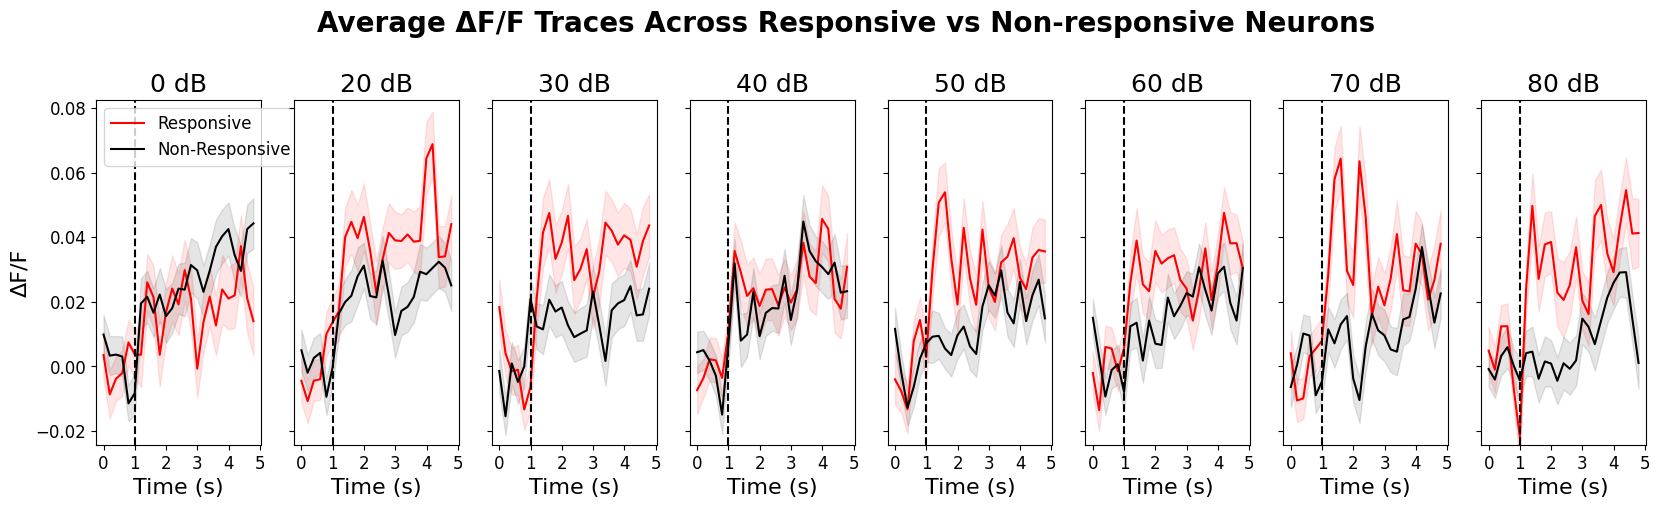

In [23]:
# Plot average dF/F re sound level (responsive neurons vs non-responsive neurons)

# Compute global ymin / ymax across all sound levels
ymins, ymaxs = [], []
for level in sorted(df_resp['dB'].unique()):
    # Extract responsive and non-responsive traces from df_resp
    resp_traces = np.stack(df_resp.loc[(df_resp['dB'] == level) & (df_resp['responsive_neuron']), 'dFF_trace'].values)
    nonResp_traces = np.stack(df_resp.loc[(df_resp['dB'] == level) & (~df_resp['responsive_neuron']), 'dFF_trace'].values)
    avg_resp_traces, _, _ = signalProcess.meanPlusMinusSem(resp_traces, ignoreNaN=True)
    avg_nonResp_traces, _, _ = signalProcess.meanPlusMinusSem(nonResp_traces, ignoreNaN=True)
    
    ymins.append(min(np.nanmin(avg_resp_traces), np.nanmin(avg_nonResp_traces)))
    ymaxs.append(max(np.nanmax(avg_resp_traces), np.nanmax(avg_nonResp_traces)))

ymin, ymax = np.min(ymins) * 1.1, np.max(ymaxs) * 1.2
# ymin, ymax = -0.05, 0.15

# Compute common X axis ticks
trace_len_max = df_resp['dFF_trace'].apply(lambda x: len(x)).max()
timeVector_common = np.insert(timeVector[:trace_len_max-1], 0, 0)

fig, ax = plt.subplots(1, len(sorted(df_resp['dB'].unique())), figsize=(20, 5))
for i, level in enumerate(sorted(df_resp['dB'].unique())):
    # Extract traces for responsive and non-responsive neurons
    resp_traces = np.stack(df_resp.loc[(df_resp['dB'] == level) & (df_resp['responsive_neuron']), 'dFF_trace'].values)
    nonResp_traces = np.stack(df_resp.loc[(df_resp['dB'] == level) & (~df_resp['responsive_neuron']), 'dFF_trace'].values)
    
    # Compute mean ± SEM
    avg_resp_traces, resp_traces_psem, resp_traces_msem = signalProcess.meanPlusMinusSem(resp_traces, ignoreNaN=True)
    avg_nonResp_traces, nonResp_traces_psem, nonResp_traces_msem = signalProcess.meanPlusMinusSem(nonResp_traces, ignoreNaN=True)
    
    # Get time vector within the display window (starting from 0)
    timeVector_seg = np.insert(timeVector[:avg_resp_traces.shape[0]-1], 0, 0)
    
    ax[i].plot(timeVector_seg, avg_resp_traces, color='r', label='Responsive')
    ax[i].fill_between(timeVector_seg, resp_traces_psem, resp_traces_msem, color='r', alpha=0.1)
    ax[i].plot(timeVector_seg, avg_nonResp_traces, color='k', label='Non-Responsive')
    ax[i].fill_between(timeVector_seg, nonResp_traces_psem, nonResp_traces_msem, color='k', alpha=0.1)
    ax[i].axvline(x=-t_base[0], color='k', linestyle='--')
    ax[i].set_title(f'{level} dB', fontsize=18)
    ax[i].set_xlabel('Time (s)', fontsize=16)
    ax[i].set_ylim(ymin, ymax)
    ax[i].set_xticks(np.arange(min(timeVector_common), max(timeVector_common) + 1, 1))
    ax[i].tick_params(axis='both', labelsize=12)
    if i == 0:
        ax[i].set_ylabel('ΔF/F', fontsize=16)
        ax[i].legend(fontsize=12, loc='upper left')
    else:
        ax[i].set_yticklabels([])

fig.suptitle('Average ΔF/F Traces Across Responsive vs Non-responsive Neurons', fontsize=20, fontweight='bold')
fig.subplots_adjust(top=0.8)

plt.show()

In [24]:
len(respIndices), len(respIndices) + len(nonRespIndices)

(189, 462)

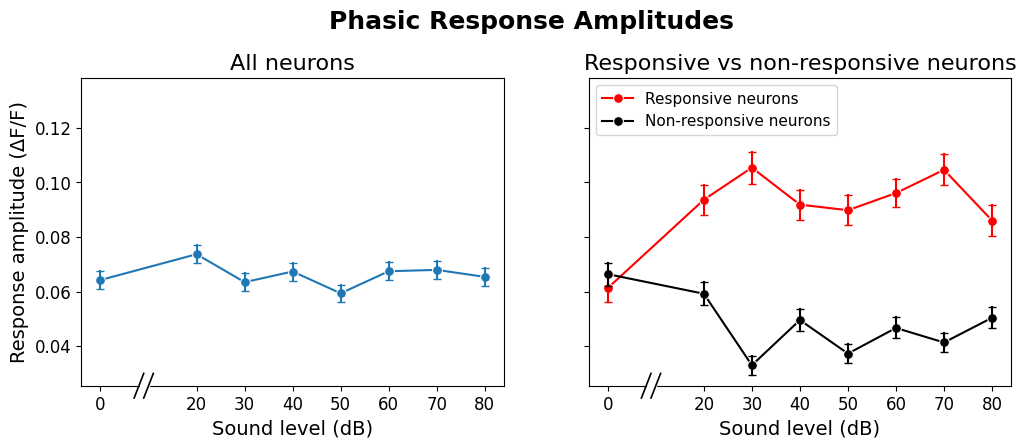

In [9]:
import seaborn as sns
palette = {'Responsive neurons': 'r', 'Non-responsive neurons': 'k'}

# Customize x positions of sound levels with a gap between 0 dB and 20 dB
levels_sorted = sorted(df_resp['dB'].unique())
xpos = np.arange(len(levels_sorted))
xpos[1:] += 1
level2xpos = dict(zip(levels_sorted, xpos))

# Convert df_resp to long-format DataFrame including all neurons
df_all_long = pd.DataFrame({
    'Sound level (dB)': df_resp['dB'],
    'Response': df_resp['dFF_peak_phasic'],
    'responsive_neuron': df_resp['responsive_neuron']
})
df_all_long['xpos'] = df_all_long['Sound level (dB)'].map(level2xpos)

# Label responsive vs non-responsive neurons and convert to long-format DataFrame
df_grouped_long = df_all_long.copy()
df_grouped_long['Group'] = 'Non-responsive neurons'
df_grouped_long.loc[df_grouped_long['responsive_neuron'], 'Group'] = 'Responsive neurons'

# Plot lineplots for all neurons and grouped by responsiveness
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.lineplot(data=df_all_long, x='xpos', y='Response', errorbar='se', 
             err_style='bars', err_kws={'capsize':3}, marker='o', markersize=7, ax=ax[0])
ax[0].set_title('All neurons', fontsize=16)
ax[0].set_ylabel('Response amplitude (ΔF/F)', fontsize=14)

sns.lineplot(data=df_grouped_long, x='xpos', y='Response', hue='Group', 
             hue_order=['Responsive neurons', 'Non-responsive neurons'], palette=palette, 
             errorbar='se', err_style='bars', err_kws={'capsize':3}, 
             marker='o', markersize=7, ax=ax[1])
ax[1].set_title('Responsive vs non-responsive neurons', fontsize=16)
ax[1].legend(title=None, loc='upper left', fontsize=11)

for axn in ax:
    axn.set_xlabel('Sound level (dB)', fontsize=14)
    axn.set_xticks(xpos)
    axn.set_xticklabels(levels_sorted)
    axn.tick_params(axis='both', labelsize=12)

# Increase Y upper limit slightly
ymin, ymax = ax[0].get_ylim()
for axn in ax:
    axn.set_ylim(ymin, ymax*1.2)
    # axn.set_ylim(0, 0.25)

# Add axis break slashes between 0 dB and 20 dB
break_x = (xpos[0] + xpos[1]) / 2

for axn in ax:
    # hide spine segment using white overlay
    axn.plot([break_x-0.1, break_x-0.05], [0, 0], 
             transform=axn.get_xaxis_transform(), 
             color='white', linewidth=6, clip_on=False, zorder=10)

    # Add slashes
    dx, dy = 0.10, 0.04
    kwargs = dict(transform=axn.get_xaxis_transform(), color='k', 
                  clip_on=False, linewidth=1.2, zorder=11)
    axn.plot([break_x-dx, break_x+dx], [-dy, +dy], **kwargs)
    axn.plot([break_x-3*dx, break_x-dx], [-dy, +dy], **kwargs)

fig.suptitle('Phasic Response Amplitudes', fontsize=18, fontweight='bold', y=1.05)
plt.show()

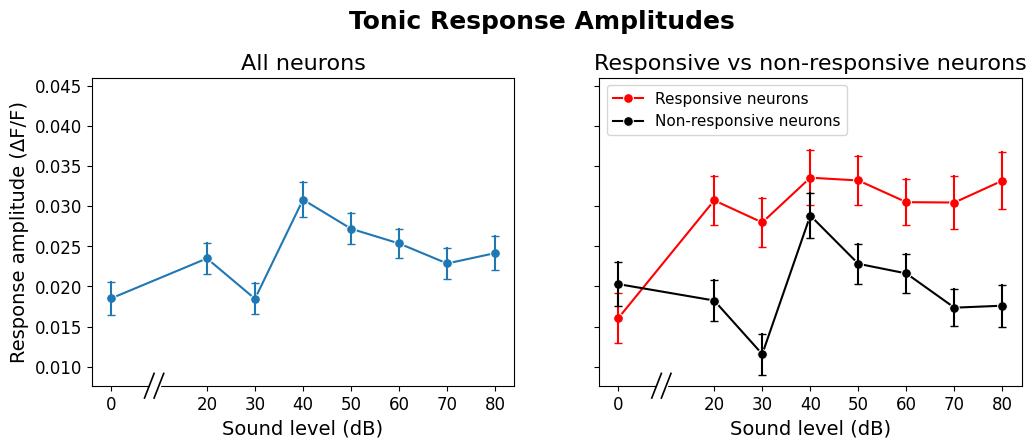

In [11]:
palette = {'Responsive neurons': 'r', 'Non-responsive neurons': 'k'}

# Customize x positions of sound levels with a gap between 0 dB and 20 dB
levels_sorted = sorted(df_resp['dB'].unique())
xpos = np.arange(len(levels_sorted))
xpos[1:] += 1  # add a gap after 0 dB
level2xpos = dict(zip(levels_sorted, xpos))

# Convert df_resp to long-format DataFrame including all neurons (tonic responses)
df_all_long = pd.DataFrame({
    'Sound level (dB)': df_resp['dB'],
    'Response': df_resp['dFF_avg_tonic'],
    'responsive_neuron': df_resp['responsive_neuron']
})
df_all_long['xpos'] = df_all_long['Sound level (dB)'].map(level2xpos)

# Label responsive vs non-responsive neurons and convert to long-format DataFrame
df_grouped_long = df_all_long.copy()
df_grouped_long['Group'] = 'Non-responsive neurons'
df_grouped_long.loc[df_grouped_long['responsive_neuron'], 'Group'] = 'Responsive neurons'

# Plot lineplots for all neurons and grouped by responsiveness
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.lineplot(data=df_all_long, x='xpos', y='Response', errorbar='se', 
             err_style='bars', err_kws={'capsize':3}, marker='o', markersize=7, ax=ax[0])
ax[0].set_title('All neurons', fontsize=16)
ax[0].set_ylabel('Response amplitude (ΔF/F)', fontsize=14)

sns.lineplot(data=df_grouped_long, x='xpos', y='Response', hue='Group', 
             hue_order=['Responsive neurons', 'Non-responsive neurons'], palette=palette, 
             errorbar='se', err_style='bars', err_kws={'capsize':3}, 
             marker='o', markersize=7, ax=ax[1])
ax[1].set_title('Responsive vs non-responsive neurons', fontsize=16)
ax[1].legend(title=None, loc='upper left', fontsize=11)

for axn in ax:
    axn.set_xlabel('Sound level (dB)', fontsize=14)
    axn.set_xticks(xpos)
    axn.set_xticklabels(levels_sorted)
    axn.tick_params(axis='both', labelsize=12)

# Increase Y upper limit slightly
ymin, ymax = ax[0].get_ylim()
for axn in ax:
    axn.set_ylim(ymin, ymax*1.2)
    # axn.set_ylim(-0.025, 0.15)

# Add axis break slashes between 0 dB and 20 dB
break_x = (xpos[0] + xpos[1]) / 2

for axn in ax:
    # hide spine segment using white overlay
    axn.plot([break_x-0.1, break_x-0.05], [0, 0], 
             transform=axn.get_xaxis_transform(), 
             color='white', linewidth=6, clip_on=False, zorder=10)

    # Add slashes
    dx, dy = 0.10, 0.04
    kwargs = dict(transform=axn.get_xaxis_transform(), color='k', 
                  clip_on=False, linewidth=1.2, zorder=11)
    axn.plot([break_x-dx, break_x+dx], [-dy, +dy], **kwargs)
    axn.plot([break_x-3*dx, break_x-dx], [-dy, +dy], **kwargs)

fig.suptitle('Tonic Response Amplitudes', fontsize=18, fontweight='bold', y=1.05)
plt.show()

In [ ]:
# import joblib
# joblib.dump(df_resp, '../data/cache/2pResp_WT_preZX1.joblib')

['../data/cache/2pResp_WT_preZX1.joblib']

## Broadband train (postZX1)

In [4749]:
import lib.signalProcess as signalProcess
import numpy as np

# WT
resp2pPaths = [
    r"C:\Data\Shengjie Data\TLB10-GRISZ\20260406\AA0001\AA0001\GRISZ_20260406_BB_postZX1_rawFluoWholeTraces.mat", 
    r"C:\Data\Shengjie Data\TLB10-GRISZ\20260407\AA0001\AA0001\GRISZ_20260407_BB_postZX1_rawFluoWholeTraces.mat", 
    r"C:\Data\Shengjie Data\TLB10-GRISZ\20260413\postZX1\AA0001\GRISZ_20260413_BB_postZX1_rawFluoWholeTraces.mat", 
    r"C:\Data\Shengjie Data\TLB10-GRISZ\20260414\AA0001\AA0001\GRISZ_20260414_BB_postZX1_rawFluoWholeTraces.mat"
]

# ZnT3 Cre/ROX (conditionally ZnT3 KO)
# resp2pPaths = [
#     r"C:\Data\Shengjie Data\TLB10-GRISZ\20260316\AA0001\AA0001\GRISZ_20260316_BB_postZX1_rawFluoWholeTraces.mat", 
#     r"C:\Data\Shengjie Data\TLB10-GRISZ\20260318\AA0001\AA0001\GRISZ_20260318_BB_postZX1_rawFluoWholeTraces.mat", 
#     r"C:\Data\Shengjie Data\TLB10-GRISZ\20260323\AA0001\AA0001\GRISZ_20260323_BB_postZX1_rawFluoWholeTraces.mat"
# ]

t_base = (-1, 0)  # Specify baseline window relative to sound onset
t_resp_phasic = (0.3, 1.3)  # Specify response (phasic) window relative to sound onset
t_resp_tonic = (2, 3.9)  # Specify response (tonic) window relative to sound onset

# Extract metadata and aligned raw F traces
levelOrder, soundOnsets, timeVector, rawWholeTraces_list = signalProcess.align2pRawTraces(resp2pPaths, alignMethod='pad', lowpassFreq=2, add0dB=True)

# rawWholeTraces_list_processed = rawWholeTraces_list
# Process raw F traces by excluding negative trace segments
rawWholeTraces_list_processed = signalProcess.process_2pRawTraces(
    rawWholeTraces_list, timeVector, soundOnsets, t_base=t_base, t_resp_phasic=t_resp_phasic, t_resp_tonic=t_resp_tonic)

Extracted raw whole fluorescence traces [traceNumber, neuronNumber, frame] of shape: (14, 99, 260)
Extracted raw whole fluorescence traces [traceNumber, neuronNumber, frame] of shape: (11, 87, 260)
Extracted raw whole fluorescence traces [traceNumber, neuronNumber, frame] of shape: (10, 130, 260)
Extracted raw whole fluorescence traces [traceNumber, neuronNumber, frame] of shape: (12, 146, 260)


In [ ]:
# temp = rawWholeTraces_list_processed[0][9, :, :][np.newaxis, :, :]
# temp = np.delete(rawWholeTraces_list_processed[0], [9], axis=0)
# rawWholeTraces_list_processed = []
# rawWholeTraces_list_processed.append(temp)


# temp = np.delete(rawWholeTraces_list_processed[-1], [4], axis=0)
# temp_remainder = rawWholeTraces_list_processed[:-1]
# rawWholeTraces_list_processed = []
# rawWholeTraces_list_processed.append(temp)
# rawWholeTraces_list_processed = temp_remainder + rawWholeTraces_list_processed

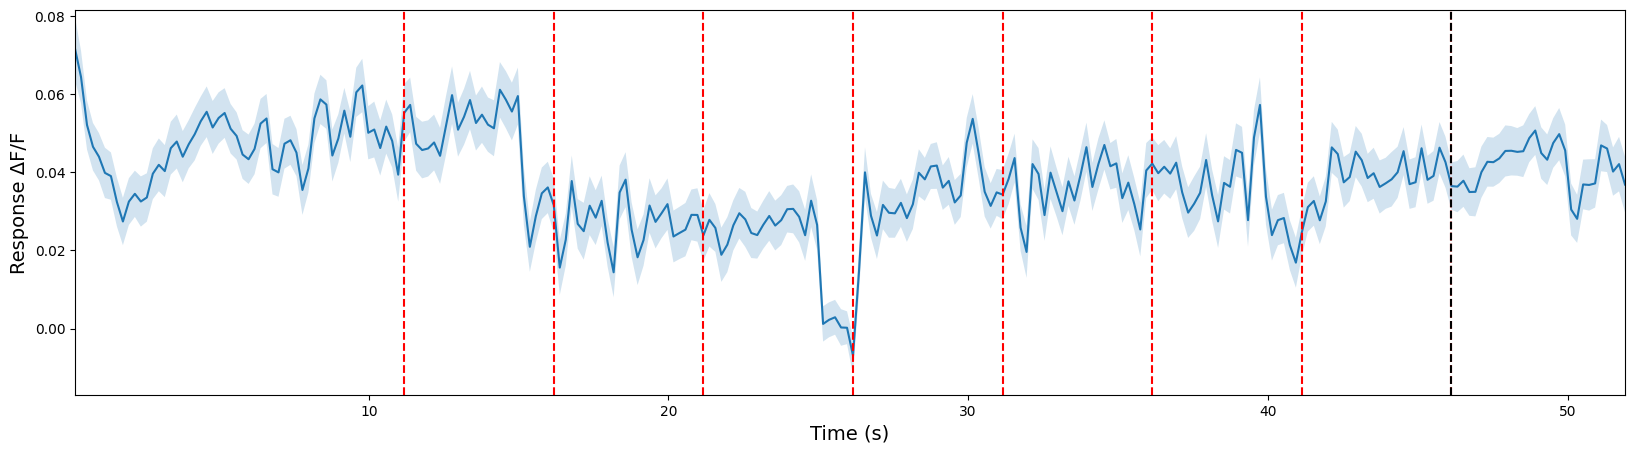

In [ ]:
# Preview whole traces with specified baseline
import matplotlib.pyplot as plt

# Find the closest time point to first sound onset - 5s as prepend stimulus to reduce adaptation effect
soundOnset_prepend = timeVector[np.argmin(np.abs(timeVector - (soundOnsets[0] - np.mean(np.diff(soundOnsets)))))]

soundOnset_selected = soundOnsets[0]
# soundOnset_selected = soundOnsets[-1]  # 0 dB control
# soundOnset_selected = soundOnset_prepend

dFFwholeTraces_list = signalProcess.compute_2pDFFtraces(rawWholeTraces_list_processed, timeVector, soundOnset_selected, t_base=t_base, t_resp=t_resp_phasic)
dFFwholeTraces_trialAvg = np.concatenate(
    [np.nanmean(dFFwholeTrace, axis=0) for dFFwholeTrace in dFFwholeTraces_list], 
    axis=0
)

# Average traces across all neurons
avg_traces, traces_psem, traces_msem = signalProcess.meanPlusMinusSem(dFFwholeTraces_trialAvg, ignoreNaN=True)  # Handle NaNs if any
ymin, ymax = np.nanmin(avg_traces) - 0.01, np.nanmax(avg_traces) + 0.01

fig, ax = plt.subplots(figsize=(20, 5))
# for i in range(dFFwholeTraces_trialAvg.shape[0]):
#     ax.plot(timeVector, dFFwholeTraces_trialAvg[i, :], color='gray', alpha=0.02)
ax.plot(timeVector, avg_traces)
ax.fill_between(timeVector, traces_psem, traces_msem, alpha=0.2)
for soundOnset in soundOnsets:
    ax.axvline(x=soundOnset, color='red', linestyle='--')
ax.set_xlabel('Time (s)', fontsize=14)
ax.set_ylabel('Response ΔF/F', fontsize=14)
ax.set_xlim(timeVector[0], timeVector[-1])
ax.set_ylim(ymin, ymax)
ax.axvline(x=soundOnsets[-1], color='k', linestyle='--')  # 0 dB control
# ax.axvline(x=soundOnset_prepend, color='orange', linestyle='--')

plt.show()

In [4751]:
# Initialize a dict mapping sound levels to their corresponding dF/F trace segments (from soundOnset-1 to soundOnset+4)
import pandas as pd
dB2trace = {}

for i in range(len(levelOrder)):
    dFFwholeTraces_list = signalProcess.compute_2pDFFtraces(rawWholeTraces_list_processed, timeVector, soundOnsets[i], t_base=t_base, t_resp=t_resp_phasic)
    dFFwholeTraces_trialAvg = np.concatenate(
        [np.nanmean(dFFwholeTrace, axis=0) for dFFwholeTrace in dFFwholeTraces_list], 
        axis=0
    )
    windowInd = np.where((timeVector >= soundOnsets[i] + t_base[0]) & (timeVector <= soundOnsets[i] + t_resp_tonic[1]))[0]
    dB2trace[levelOrder[i]] = dFFwholeTraces_trialAvg[:, windowInd]

# Store dF/F traces across sound levels and neuron indices in a DataFrame
df_resp = pd.DataFrame([
    {'dB': dB, 'neuronIDX': i, 'dFF_trace': arr[i, :]}
    for dB, arr in dB2trace.items()
    for i in range(arr.shape[0])
])
df_resp

,dB,neuronIDX,dFF_trace
0,30,0,"[-0.004911986798919961, 0.013483339637455244, ..."
1,30,1,"[-0.0049521636153499644, -0.030464018544825486..."
2,30,2,"[0.010300164414565749, -0.12030144297792406, -..."
3,30,3,"[-0.05605816868952099, 0.04333898127473612, 0...."
4,30,4,"[0.07650992759777249, -0.008091666097931239, -..."
...,...,...,...
3691,0,457,"[-0.02033834859140191, -0.013209381971572913, ..."
3692,0,458,"[0.0003868416526720214, -0.06001517576540682, ..."
3693,0,459,"[0.0017418667103333437, -0.17786808622775738, ..."
3694,0,460,"[0.2305130382177563, 0.03841256540614237, -0.0..."


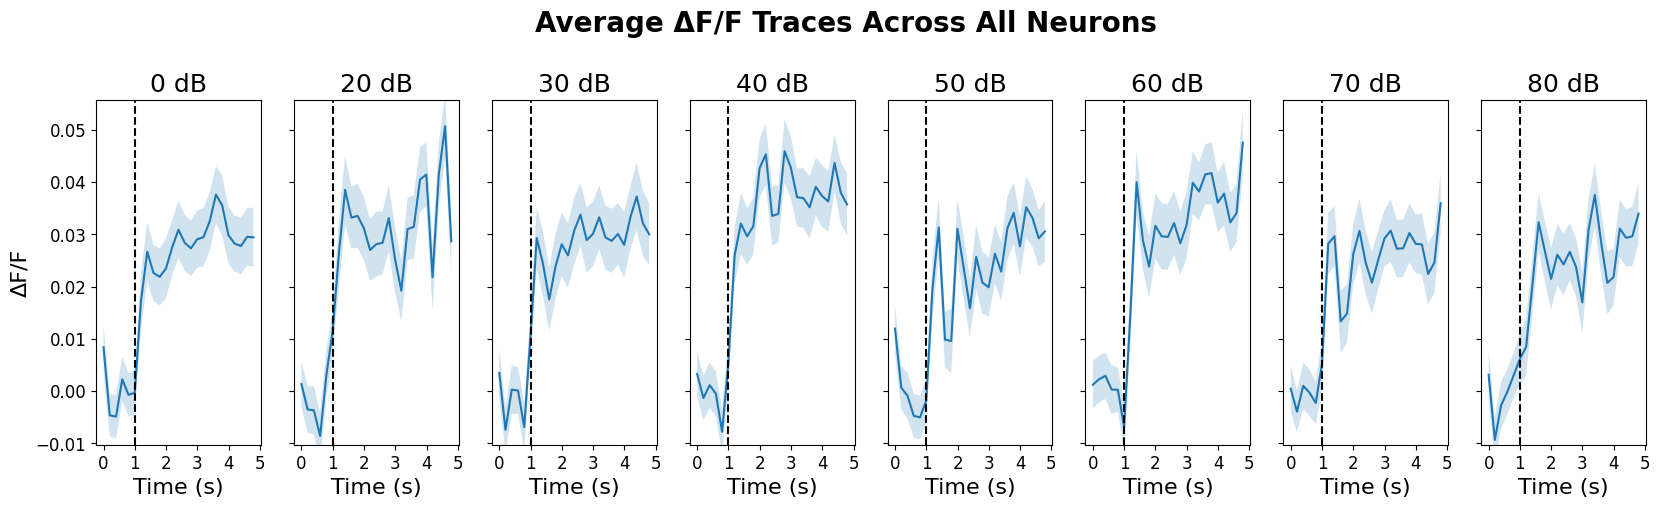

In [4752]:
# Plot average dF/F re sound level (all neurons)

# Get unique sound levels
levels = sorted(df_resp['dB'].unique())

# Compute global ymin / ymax across all sound levels
ymins, ymaxs = [], []
for level in levels:
    traces = np.stack(df_resp[df_resp['dB'] == level]['dFF_trace'].values)
    avg_traces, _, _ = signalProcess.meanPlusMinusSem(traces, ignoreNaN=True)
    ymins.append(np.nanmin(avg_traces))
    ymaxs.append(np.nanmax(avg_traces))
ymin, ymax = np.min(ymins) * 1.1, np.max(ymaxs) * 1.1
# ymin, ymax = -0.05, 0.15

# Compute common X axis ticks
trace_len_max = max(len(trace) for trace in df_resp['dFF_trace'])
timeVector_common = np.insert(timeVector[:trace_len_max-1], 0, 0)

fig, ax = plt.subplots(1, len(levels), figsize=(20, 5))
for i, level in enumerate(levels):
    traces = np.stack(df_resp[df_resp['dB'] == level]['dFF_trace'].values)
    avg_traces, traces_psem, traces_msem = signalProcess.meanPlusMinusSem(traces, ignoreNaN=True)  # Handle NaNs if any
    
    # Get time vector within the display window (starting from 0)
    timeVector_seg = np.insert(timeVector[:avg_traces.shape[0]-1], 0, 0)
    
    ax[i].plot(timeVector_seg, avg_traces)
    ax[i].fill_between(timeVector_seg, traces_psem, traces_msem, alpha=0.2)
    ax[i].axvline(x=-t_base[0], color='k', linestyle='--')
    ax[i].set_title(f'{level} dB', fontsize=18)
    ax[i].set_xlabel('Time (s)', fontsize=16)
    ax[i].set_ylim(ymin, ymax)
    ax[i].set_xticks(np.arange(min(timeVector_common), max(timeVector_common) + 1, 1))
    ax[i].tick_params(axis='both', labelsize=12)
    if i == 0:
        ax[i].set_ylabel('ΔF/F', fontsize=16)
    else:
        ax[i].set_yticklabels([])

fig.suptitle('Average ΔF/F Traces Across All Neurons', fontsize=20, fontweight='bold')
fig.subplots_adjust(top=0.8)

plt.show()

In [4753]:
# Get indices of responsive neurons (neurons that are responsive at at least two consecutive sound levels)

thres_SD = 2  # Specify criteria threshold
nonSignificant2Zero_phasic = True  # Whether to replace non-significant phasic responses with zeros
nonSignificant2Zero_tonic = False  # Whether to replace non-significant tonic responses with zeros
avgAdjacentFrames = False  # Whether to average peak amplitude with adjacent two frames (±1 frame) to reduce noise

# Initialize new columns in df_resp
df_resp['responsive_level'] = False
df_resp['dFF_peak_phasic'] = np.nan
df_resp['dFF_avg_tonic'] = np.nan

for level in sorted(df_resp['dB'].unique()):  # Including 0 dB
    # Reconstruct traces from df_resp (shape: [neuronNumber, frame])
    mask = df_resp['dB'] == level
    traces = np.stack(df_resp.loc[mask, 'dFF_trace'].values)
    
    # Get time vector within the display window (starting from 0)
    timeVector_seg = np.insert(timeVector[:traces.shape[1]-1], 0, 0)
    
    # Compute baseline and phasic response
    base, resp = signalProcess.getBaseResp(
        traces, timeVector_seg,
        t_base=(0, t_base[1] - t_base[0]),
        t_resp=(t_resp_phasic[0] - t_base[0], t_resp_phasic[1] - t_base[0])
    )
    base_indices = np.where((timeVector_seg >= 0) & (timeVector_seg <= t_base[1] - t_base[0]))[0]
    baseSD = np.std(traces[:, base_indices], axis=1, ddof=1)  # Sample standard deviation
    
    # Get responsive neuron indices (phasic)
    respIDX = np.where(resp > base + thres_SD * baseSD)[0]

    if avgAdjacentFrames:
        # Re-calculate response by averaging peak amplitude with adjacent two frames (±1 frame)
        resp = signalProcess.getBaseResp(
            traces, timeVector_seg,
            t_base=(0, t_base[1] - t_base[0]),
            t_resp=(t_resp_phasic[0] - t_base[0], t_resp_phasic[1] - t_base[0]),
            avgAdjacentFrames=True
        )[1]

    if nonSignificant2Zero_phasic:
        # Replace non-significant phasic responses with zero while keeping significant ones
        resp[~np.isin(np.arange(len(resp)), respIDX)] = 0

    # Compute tonic response
    tonic = signalProcess.getBaseResp(
        traces, timeVector_seg,
        t_base=(0, t_base[1] - t_base[0]),
        t_resp=(t_resp_tonic[0] - t_base[0], t_resp_tonic[1] - t_base[0]),
        calMeanResp=True
    )[1]
    respIDX_tonic = np.where(tonic > base + thres_SD * baseSD)[0]

    if nonSignificant2Zero_tonic:
        # Replace non-significant tonic responses with zero while keeping significant ones
        tonic[~np.isin(np.arange(len(tonic)), respIDX_tonic)] = 0

    # Write results back to df_resp (preserve row order)
    idx = df_resp.index[mask]
    df_resp.loc[idx, 'dFF_peak_phasic'] = resp
    df_resp.loc[idx, 'dFF_avg_tonic'] = tonic
    df_resp.loc[idx, 'responsive_level'] = np.isin(np.arange(len(resp)), respIDX)

# Calculate response threshold re neuron
levels_sorted = [dB for dB in sorted(levelOrder) if dB != 0]  # Exclude 0 dB if present

# Get total neuron number
n_neurons = df_resp['neuronIDX'].nunique()

# Initialize with max level as default threshold unless two consecutive sound levels with significant responses are found
threshold = np.full(n_neurons, levels_sorted[-1])

for i in range(n_neurons):
    for j in range(len(levels_sorted) - 1):  # Exclude highest level as starting point
        # Check responsiveness directly from df_resp
        is_resp_j = df_resp[(df_resp['neuronIDX'] == i) & (df_resp['dB'] == levels_sorted[j])]['responsive_level'].iloc[0]
        is_resp_j1 = df_resp[(df_resp['neuronIDX'] == i) & (df_resp['dB'] == levels_sorted[j+1])]['responsive_level'].iloc[0]
        if is_resp_j and is_resp_j1:
            # Response threshold is the lower sound level of two consecutive sound levels eliciting significant responses
            threshold[i] = levels_sorted[j]
            break

# Get indices of responsive neurons (threshold below max sound level)
# respIndices = np.where(threshold < levels_sorted[-1])[0]
# nonRespIndices = np.where(threshold == levels_sorted[-1])[0]

# Add threshold and responsive neuron info to df_resp
neuron2threshold = dict(zip(range(n_neurons), threshold))
df_resp['threshold'] = df_resp['neuronIDX'].map(neuron2threshold)
df_resp['responsive_neuron'] = df_resp['neuronIDX'].isin(respIndices)  # Use respIndices preZX1

df_resp

,dB,neuronIDX,dFF_trace,responsive_level,dFF_peak_phasic,dFF_avg_tonic,threshold,responsive_neuron
0,30,0,"[-0.004911986798919961, 0.013483339637455244, ...",True,0.150891,0.142666,50,False
1,30,1,"[-0.0049521636153499644, -0.030464018544825486...",True,0.108707,-0.001496,80,True
2,30,2,"[0.010300164414565749, -0.12030144297792406, -...",True,0.316267,0.070814,20,False
3,30,3,"[-0.05605816868952099, 0.04333898127473612, 0....",False,0.000000,-0.047031,80,False
4,30,4,"[0.07650992759777249, -0.008091666097931239, -...",False,0.000000,0.091784,80,True
...,...,...,...,...,...,...,...,...
3691,0,457,"[-0.02033834859140191, -0.013209381971572913, ...",False,0.000000,0.073943,20,False
3692,0,458,"[0.0003868416526720214, -0.06001517576540682, ...",True,0.172919,0.105124,40,True
3693,0,459,"[0.0017418667103333437, -0.17786808622775738, ...",False,0.000000,0.087213,80,True
3694,0,460,"[0.2305130382177563, 0.03841256540614237, -0.0...",False,0.000000,0.026143,30,True


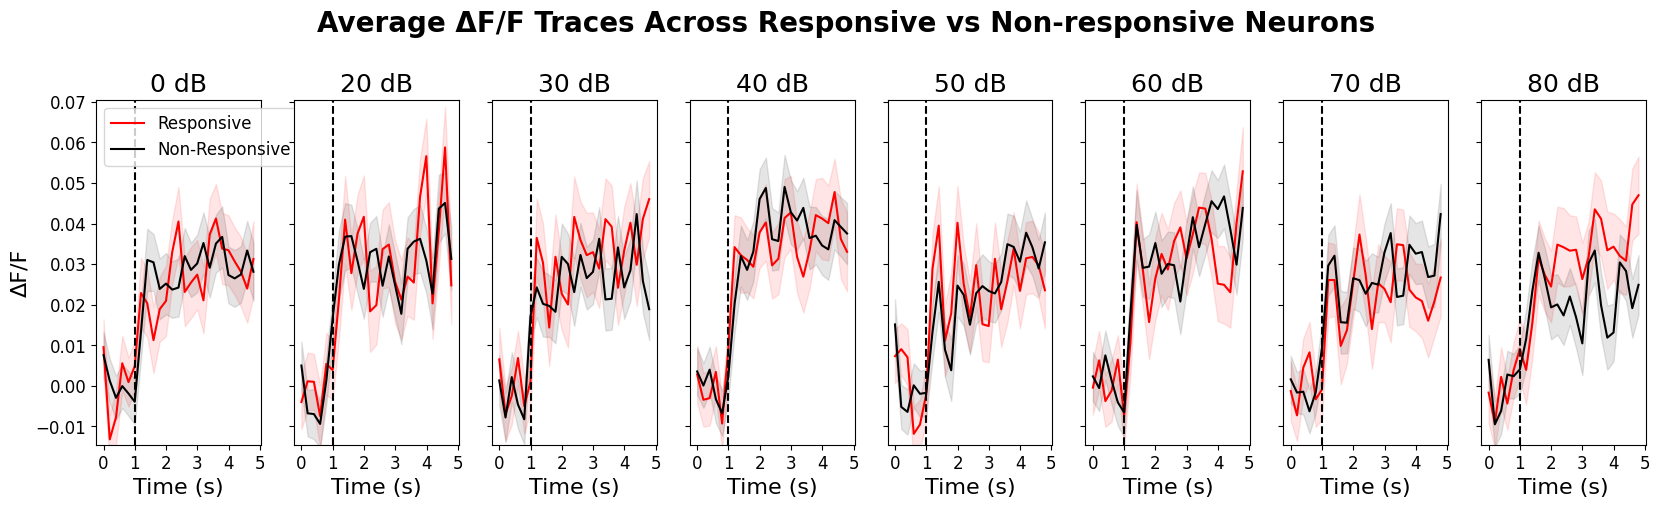

In [4754]:
# Plot average dF/F re sound level (responsive neurons vs non-responsive neurons)

# Compute global ymin / ymax across all sound levels
ymins, ymaxs = [], []
for level in sorted(df_resp['dB'].unique()):
    # Extract responsive and non-responsive traces from df_resp
    resp_traces = np.stack(df_resp.loc[(df_resp['dB'] == level) & (df_resp['responsive_neuron']), 'dFF_trace'].values)
    nonResp_traces = np.stack(df_resp.loc[(df_resp['dB'] == level) & (~df_resp['responsive_neuron']), 'dFF_trace'].values)
    avg_resp_traces, _, _ = signalProcess.meanPlusMinusSem(resp_traces, ignoreNaN=True)
    avg_nonResp_traces, _, _ = signalProcess.meanPlusMinusSem(nonResp_traces, ignoreNaN=True)
    ymins.append(min(np.nanmin(avg_resp_traces), np.nanmin(avg_nonResp_traces)))
    ymaxs.append(max(np.nanmax(avg_resp_traces), np.nanmax(avg_nonResp_traces)))

ymin, ymax = np.min(ymins) * 1.1, np.max(ymaxs) * 1.2
# ymin, ymax = -0.05, 0.15

# Compute common X axis ticks
trace_len_max = df_resp['dFF_trace'].apply(lambda x: len(x)).max()
timeVector_common = np.insert(timeVector[:trace_len_max-1], 0, 0)

fig, ax = plt.subplots(1, len(sorted(df_resp['dB'].unique())), figsize=(20, 5))
for i, level in enumerate(sorted(df_resp['dB'].unique())):
    # Extract traces for responsive and non-responsive neurons
    resp_traces = np.stack(df_resp.loc[(df_resp['dB'] == level) & (df_resp['responsive_neuron']), 'dFF_trace'].values)
    nonResp_traces = np.stack(df_resp.loc[(df_resp['dB'] == level) & (~df_resp['responsive_neuron']), 'dFF_trace'].values)
    
    # Compute mean ± SEM
    avg_resp_traces, resp_traces_psem, resp_traces_msem = signalProcess.meanPlusMinusSem(resp_traces, ignoreNaN=True)
    avg_nonResp_traces, nonResp_traces_psem, nonResp_traces_msem = signalProcess.meanPlusMinusSem(nonResp_traces, ignoreNaN=True)
    
    # Get time vector within the display window (starting from 0)
    timeVector_seg = np.insert(timeVector[:avg_resp_traces.shape[0]-1], 0, 0)
    
    ax[i].plot(timeVector_seg, avg_resp_traces, color='r', label='Responsive')
    ax[i].fill_between(timeVector_seg, resp_traces_psem, resp_traces_msem, color='r', alpha=0.1)
    ax[i].plot(timeVector_seg, avg_nonResp_traces, color='k', label='Non-Responsive')
    ax[i].fill_between(timeVector_seg, nonResp_traces_psem, nonResp_traces_msem, color='k', alpha=0.1)
    ax[i].axvline(x=-t_base[0], color='k', linestyle='--')
    ax[i].set_title(f'{level} dB', fontsize=18)
    ax[i].set_xlabel('Time (s)', fontsize=16)
    ax[i].set_ylim(ymin, ymax)
    ax[i].set_xticks(np.arange(min(timeVector_common), max(timeVector_common) + 1, 1))
    ax[i].tick_params(axis='both', labelsize=12)
    if i == 0:
        ax[i].set_ylabel('ΔF/F', fontsize=16)
        ax[i].legend(fontsize=12, loc='upper left')
    else:
        ax[i].set_yticklabels([])

fig.suptitle('Average ΔF/F Traces Across Responsive vs Non-responsive Neurons', fontsize=20, fontweight='bold')
fig.subplots_adjust(top=0.8)

plt.show()

In [4755]:
len(respIndices), len(respIndices) + len(nonRespIndices)

(189, 462)

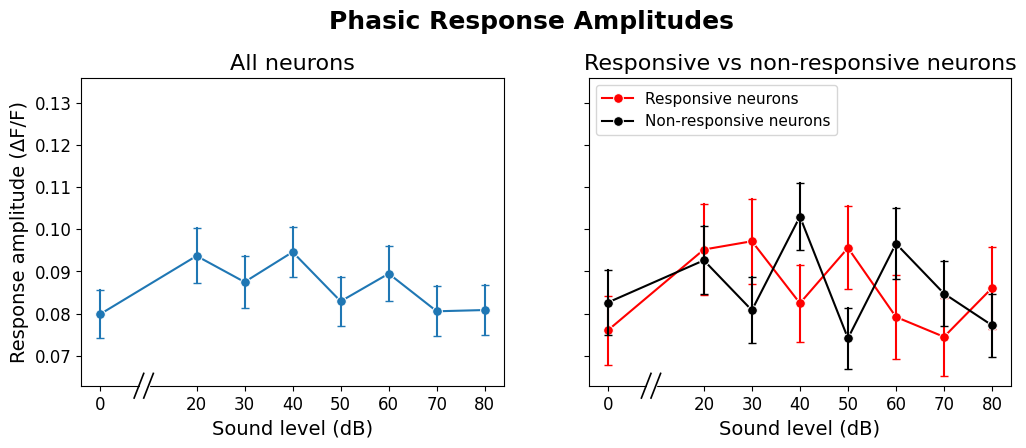

In [4756]:
import seaborn as sns
palette = {'Responsive neurons': 'r', 'Non-responsive neurons': 'k'}

# Customize x positions of sound levels with a gap between 0 dB and 20 dB
levels_sorted = sorted(df_resp['dB'].unique())
xpos = np.arange(len(levels_sorted))
xpos[1:] += 1
level2xpos = dict(zip(levels_sorted, xpos))

# Convert df_resp to long-format DataFrame including all neurons
df_all_long = pd.DataFrame({
    'Sound level (dB)': df_resp['dB'],
    'Response': df_resp['dFF_peak_phasic'],
    'responsive_neuron': df_resp['responsive_neuron']
})
df_all_long['xpos'] = df_all_long['Sound level (dB)'].map(level2xpos)

# Label responsive vs non-responsive neurons and convert to long-format DataFrame
df_grouped_long = df_all_long.copy()
df_grouped_long['Group'] = 'Non-responsive neurons'
df_grouped_long.loc[df_grouped_long['responsive_neuron'], 'Group'] = 'Responsive neurons'

# Plot lineplots for all neurons and grouped by responsiveness
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.lineplot(data=df_all_long, x='xpos', y='Response', errorbar='se', 
             err_style='bars', err_kws={'capsize':3}, marker='o', markersize=7, ax=ax[0])
ax[0].set_title('All neurons', fontsize=16)
ax[0].set_ylabel('Response amplitude (ΔF/F)', fontsize=14)

sns.lineplot(data=df_grouped_long, x='xpos', y='Response', hue='Group', 
             hue_order=['Responsive neurons', 'Non-responsive neurons'], palette=palette, 
             errorbar='se', err_style='bars', err_kws={'capsize':3}, 
             marker='o', markersize=7, ax=ax[1])
ax[1].set_title('Responsive vs non-responsive neurons', fontsize=16)
ax[1].legend(title=None, loc='upper left', fontsize=11)

for axn in ax:
    axn.set_xlabel('Sound level (dB)', fontsize=14)
    axn.set_xticks(xpos)
    axn.set_xticklabels(levels_sorted)
    axn.tick_params(axis='both', labelsize=12)

# Increase Y upper limit slightly
ymin, ymax = ax[0].get_ylim()
for axn in ax:
    axn.set_ylim(ymin, ymax*1.2)
    # axn.set_ylim(0, 0.25)

# Add axis break slashes between 0 dB and 20 dB
break_x = (xpos[0] + xpos[1]) / 2

for axn in ax:
    # hide spine segment using white overlay
    axn.plot([break_x-0.1, break_x-0.05], [0, 0], 
             transform=axn.get_xaxis_transform(), 
             color='white', linewidth=6, clip_on=False, zorder=10)

    # Add slashes
    dx, dy = 0.10, 0.04
    kwargs = dict(transform=axn.get_xaxis_transform(), color='k', 
                  clip_on=False, linewidth=1.2, zorder=11)
    axn.plot([break_x-dx, break_x+dx], [-dy, +dy], **kwargs)
    axn.plot([break_x-3*dx, break_x-dx], [-dy, +dy], **kwargs)

fig.suptitle('Phasic Response Amplitudes', fontsize=18, fontweight='bold', y=1.05)
plt.show()

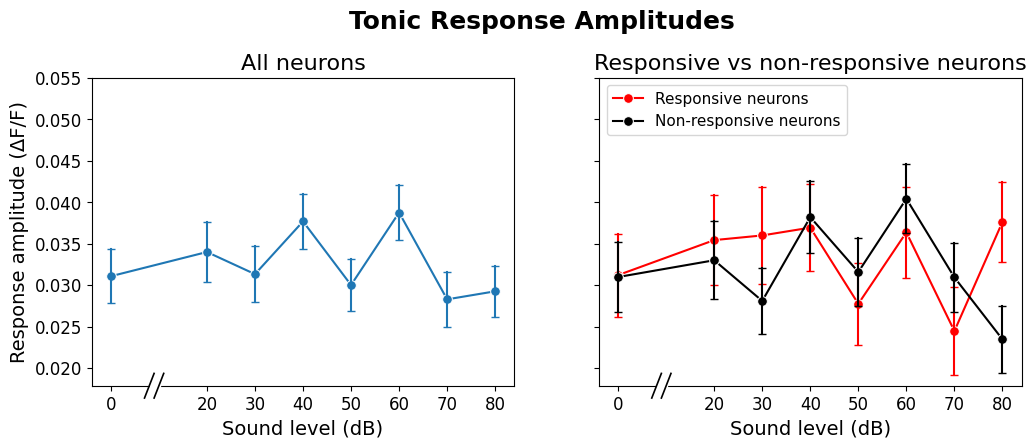

In [4757]:
palette = {'Responsive neurons': 'r', 'Non-responsive neurons': 'k'}

# Customize x positions of sound levels with a gap between 0 dB and 20 dB
levels_sorted = sorted(df_resp['dB'].unique())
xpos = np.arange(len(levels_sorted))
xpos[1:] += 1  # add a gap after 0 dB
level2xpos = dict(zip(levels_sorted, xpos))

# Convert df_resp to long-format DataFrame including all neurons (tonic responses)
df_all_long = pd.DataFrame({
    'Sound level (dB)': df_resp['dB'],
    'Response': df_resp['dFF_avg_tonic'],
    'responsive_neuron': df_resp['responsive_neuron']
})
df_all_long['xpos'] = df_all_long['Sound level (dB)'].map(level2xpos)

# Label responsive vs non-responsive neurons and convert to long-format DataFrame
df_grouped_long = df_all_long.copy()
df_grouped_long['Group'] = 'Non-responsive neurons'
df_grouped_long.loc[df_grouped_long['responsive_neuron'], 'Group'] = 'Responsive neurons'

# Plot lineplots for all neurons and grouped by responsiveness
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.lineplot(data=df_all_long, x='xpos', y='Response', errorbar='se', 
             err_style='bars', err_kws={'capsize':3}, marker='o', markersize=7, ax=ax[0])
ax[0].set_title('All neurons', fontsize=16)
ax[0].set_ylabel('Response amplitude (ΔF/F)', fontsize=14)

sns.lineplot(data=df_grouped_long, x='xpos', y='Response', hue='Group', 
             hue_order=['Responsive neurons', 'Non-responsive neurons'], palette=palette, 
             errorbar='se', err_style='bars', err_kws={'capsize':3}, 
             marker='o', markersize=7, ax=ax[1])
ax[1].set_title('Responsive vs non-responsive neurons', fontsize=16)
ax[1].legend(title=None, loc='upper left', fontsize=11)

for axn in ax:
    axn.set_xlabel('Sound level (dB)', fontsize=14)
    axn.set_xticks(xpos)
    axn.set_xticklabels(levels_sorted)
    axn.tick_params(axis='both', labelsize=12)

# Increase Y upper limit slightly
ymin, ymax = ax[0].get_ylim()
for axn in ax:
    axn.set_ylim(ymin, ymax*1.2)
    # axn.set_ylim(-0.025, 0.15)

# Add axis break slashes between 0 dB and 20 dB
break_x = (xpos[0] + xpos[1]) / 2

for axn in ax:
    # hide spine segment using white overlay
    axn.plot([break_x-0.1, break_x-0.05], [0, 0], 
             transform=axn.get_xaxis_transform(), 
             color='white', linewidth=6, clip_on=False, zorder=10)

    # Add slashes
    dx, dy = 0.10, 0.04
    kwargs = dict(transform=axn.get_xaxis_transform(), color='k', 
                  clip_on=False, linewidth=1.2, zorder=11)
    axn.plot([break_x-dx, break_x+dx], [-dy, +dy], **kwargs)
    axn.plot([break_x-3*dx, break_x-dx], [-dy, +dy], **kwargs)

fig.suptitle('Tonic Response Amplitudes', fontsize=18, fontweight='bold', y=1.05)
plt.show()

In [ ]:
# import joblib
# joblib.dump(df_resp, '../data/cache/2pResp_WT_postZX1.joblib')

['../data/cache/2pResp_WT_postZX1.joblib']

## WT vs ZnT3 KO

In [700]:
import joblib
df_resp_WT = joblib.load('../data/cache/2pResp_WT.joblib')
df_resp_ZnT3KO_conditional = joblib.load('../data/cache/2pResp_ZnT3KO_conditional.joblib')

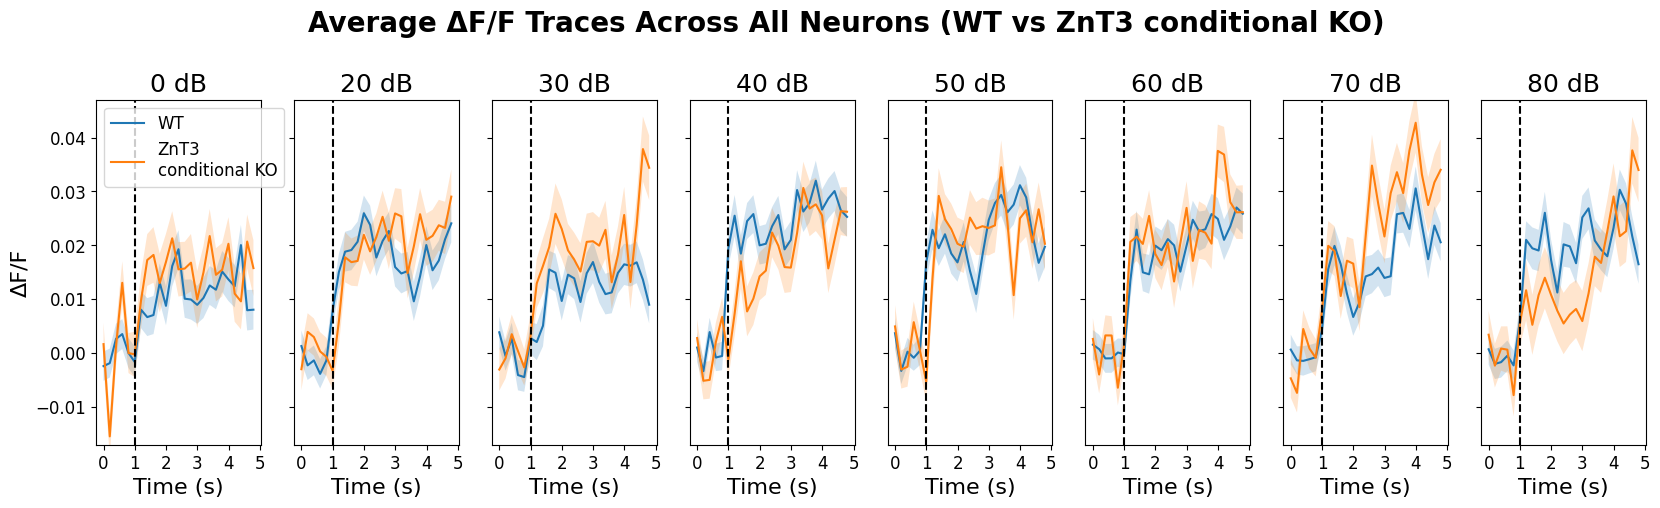

In [701]:
# Plot average dF/F traces across all neurons re sound level (WT vs conditional ZnT3 KO)
import numpy as np
import matplotlib.pyplot as plt

# Get unique sound levels (assuming both genotypes share the same levels)
levels = sorted(df_resp_WT['dB'].unique())

# Compute global ymin / ymax across all sound levels for both genotypes
ymins, ymaxs = [], []
for level in levels:
    # WT traces
    traces_WT = np.stack(df_resp_WT[df_resp_WT['dB'] == level]['dFF_trace'].values)
    avg_WT, _, _ = signalProcess.meanPlusMinusSem(traces_WT, ignoreNaN=True)
    # KO traces
    traces_KO = np.stack(df_resp_ZnT3KO_conditional[df_resp_ZnT3KO_conditional['dB'] == level]['dFF_trace'].values)
    avg_KO, _, _ = signalProcess.meanPlusMinusSem(traces_KO, ignoreNaN=True)
    
    ymins.append(min(np.nanmin(avg_WT), np.nanmin(avg_KO)))
    ymaxs.append(max(np.nanmax(avg_WT), np.nanmax(avg_KO)))

ymin, ymax = np.min(ymins) * 1.1, np.max(ymaxs) * 1.1

# Compute common X axis ticks
trace_len_max = max(
    max(len(trace) for trace in df_resp_WT['dFF_trace']),
    max(len(trace) for trace in df_resp_ZnT3KO_conditional['dFF_trace'])
)
timeVector_common = np.insert(timeVector[:trace_len_max-1], 0, 0)

fig, ax = plt.subplots(1, len(levels), figsize=(20, 5))
for i, level in enumerate(levels):
    # WT
    traces_WT = np.stack(df_resp_WT[df_resp_WT['dB'] == level]['dFF_trace'].values)
    avg_WT, WT_psem, WT_msem = signalProcess.meanPlusMinusSem(traces_WT, ignoreNaN=True)
    # KO
    traces_KO = np.stack(df_resp_ZnT3KO_conditional[df_resp_ZnT3KO_conditional['dB'] == level]['dFF_trace'].values)
    avg_KO, KO_psem, KO_msem = signalProcess.meanPlusMinusSem(traces_KO, ignoreNaN=True)
    
    # Time vector
    timeVector_seg = np.insert(timeVector[:avg_WT.shape[0]-1], 0, 0)
    
    # Plot WT traces
    ax[i].plot(timeVector_seg, avg_WT, label='WT')
    ax[i].fill_between(timeVector_seg, WT_psem, WT_msem, alpha=0.2)
    
    # Plot KO traces
    ax[i].plot(timeVector_seg, avg_KO, label='ZnT3\nconditional KO')
    ax[i].fill_between(timeVector_seg, KO_psem, KO_msem, alpha=0.2)
    
    ax[i].axvline(x=-t_base[0], color='k', linestyle='--')
    ax[i].set_title(f'{level} dB', fontsize=18)
    ax[i].set_xlabel('Time (s)', fontsize=16)
    ax[i].set_ylim(ymin, ymax)
    ax[i].set_xticks(np.arange(min(timeVector_common), max(timeVector_common) + 1, 1))
    ax[i].tick_params(axis='both', labelsize=12)
    if i == 0:
        ax[i].set_ylabel('ΔF/F', fontsize=16)
        ax[i].legend(fontsize=12, loc='upper left')
    else:
        ax[i].set_yticklabels([])

fig.suptitle('Average ΔF/F Traces Across All Neurons (WT vs ZnT3 conditional KO)', fontsize=20, fontweight='bold')
fig.subplots_adjust(top=0.8)

plt.show()

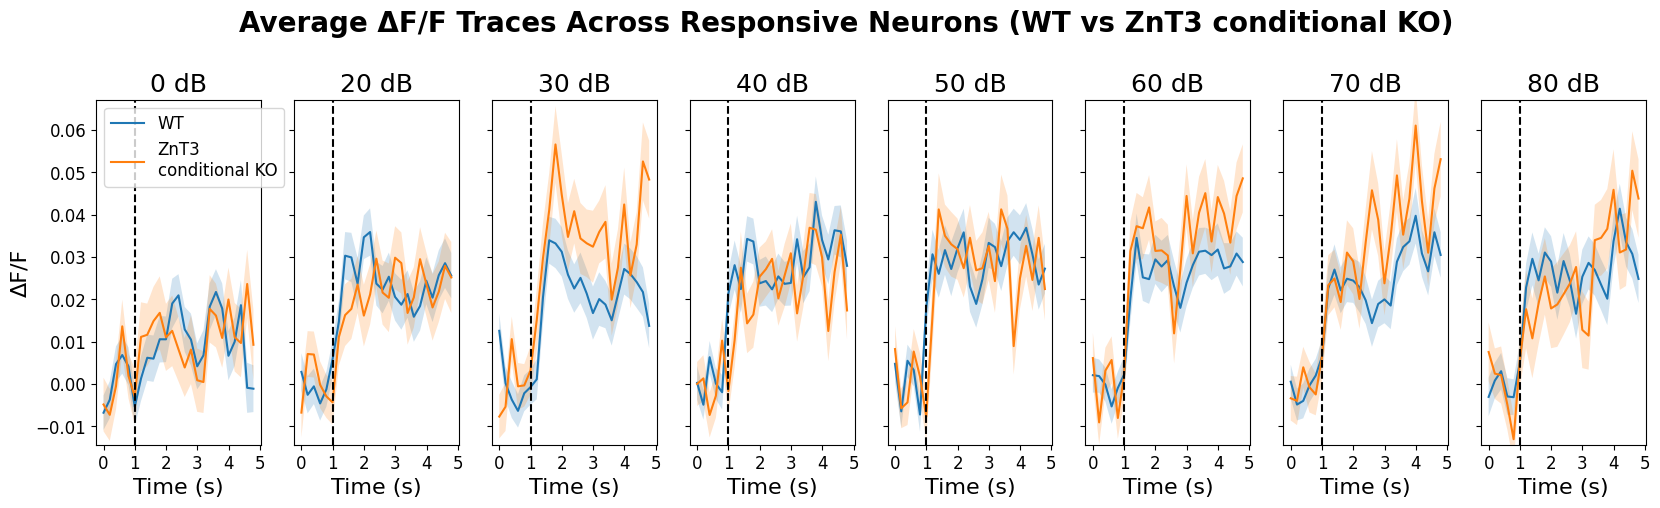

In [702]:
# Plot average dF/F traces across responsive neurons re sound level (WT vs conditional ZnT3 KO)

# Get unique sound levels (assuming both genotypes share the same levels)
levels = sorted(df_resp_WT['dB'].unique())

# Compute global ymin / ymax across all sound levels (responsive neurons only)
ymins, ymaxs = [], []
for level in levels:
    # WT responsive neurons
    resp_WT = np.stack(df_resp_WT.loc[(df_resp_WT['dB'] == level) & 
                                      (df_resp_WT['responsive_neuron']), 'dFF_trace'].values)
    avg_WT, _, _ = signalProcess.meanPlusMinusSem(resp_WT, ignoreNaN=True)
    
    # KO responsive neurons
    resp_KO = np.stack(df_resp_ZnT3KO_conditional.loc[(df_resp_ZnT3KO_conditional['dB'] == level) & 
                                                      (df_resp_ZnT3KO_conditional['responsive_neuron']), 'dFF_trace'].values)
    avg_KO, _, _ = signalProcess.meanPlusMinusSem(resp_KO, ignoreNaN=True)
    
    ymins.append(min(np.nanmin(avg_WT), np.nanmin(avg_KO)))
    ymaxs.append(max(np.nanmax(avg_WT), np.nanmax(avg_KO)))

ymin, ymax = np.min(ymins) * 1.1, np.max(ymaxs) * 1.1

# Compute common X axis ticks
trace_len_max = max(
    df_resp_WT['dFF_trace'].apply(len).max(),
    df_resp_ZnT3KO_conditional['dFF_trace'].apply(len).max()
)
timeVector_common = np.insert(timeVector[:trace_len_max-1], 0, 0)

fig, ax = plt.subplots(1, len(levels), figsize=(20, 5))
for i, level in enumerate(levels):
    # Extract responsive traces for WT
    resp_WT = np.stack(df_resp_WT.loc[(df_resp_WT['dB'] == level) & 
                                      (df_resp_WT['responsive_neuron']), 'dFF_trace'].values)
    avg_WT, psem_WT, msem_WT = signalProcess.meanPlusMinusSem(resp_WT, ignoreNaN=True)
    
    # Extract responsive traces for KO
    resp_KO = np.stack(df_resp_ZnT3KO_conditional.loc[(df_resp_ZnT3KO_conditional['dB'] == level) & 
                                                      (df_resp_ZnT3KO_conditional['responsive_neuron']), 'dFF_trace'].values)
    avg_KO, psem_KO, msem_KO = signalProcess.meanPlusMinusSem(resp_KO, ignoreNaN=True)
    
    # Time vector within display window
    timeVector_seg = np.insert(timeVector[:avg_WT.shape[0]-1], 0, 0)
    
    # Plot WT
    ax[i].plot(timeVector_seg, avg_WT, label='WT')
    ax[i].fill_between(timeVector_seg, psem_WT, msem_WT, alpha=0.2)
    
    # Plot KO
    ax[i].plot(timeVector_seg, avg_KO, label='ZnT3\nconditional KO')
    ax[i].fill_between(timeVector_seg, psem_KO, msem_KO, alpha=0.2)
    
    ax[i].axvline(x=-t_base[0], color='k', linestyle='--')
    ax[i].set_title(f'{level} dB', fontsize=18)
    ax[i].set_xlabel('Time (s)', fontsize=16)
    ax[i].set_ylim(ymin, ymax)
    ax[i].set_xticks(np.arange(min(timeVector_common), max(timeVector_common) + 1, 1))
    ax[i].tick_params(axis='both', labelsize=12)
    if i == 0:
        ax[i].set_ylabel('ΔF/F', fontsize=16)
        ax[i].legend(fontsize=12, loc='upper left')
    else:
        ax[i].set_yticklabels([])

fig.suptitle('Average ΔF/F Traces Across Responsive Neurons (WT vs ZnT3 conditional KO)', fontsize=20, fontweight='bold')
fig.subplots_adjust(top=0.8)

plt.show()

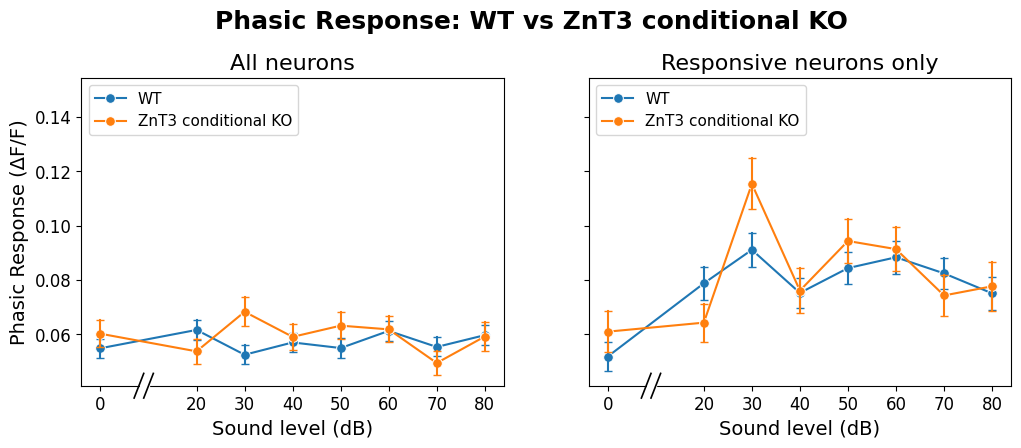

In [703]:
# Plot phasic response amplitudes across sound levels (WT vs conditional ZnT3 KO)
import pandas as pd
import seaborn as sns

# Get unique sound levels (assuming both genotypes share the same levels)
levels_sorted = sorted(df_resp_WT['dB'].unique())
xpos = np.arange(len(levels_sorted))
xpos[1:] += 1
level2xpos = dict(zip(levels_sorted, xpos))

# Convert to long-format DataFrame: all neurons
df_all_WT = pd.DataFrame({
    'Sound level (dB)': df_resp_WT['dB'],
    'Response': df_resp_WT['dFF_peak_phasic']
})
df_all_WT['Genotype'] = 'WT'
df_all_WT['xpos'] = df_all_WT['Sound level (dB)'].map(level2xpos)

df_all_KO = pd.DataFrame({
    'Sound level (dB)': df_resp_ZnT3KO_conditional['dB'],
    'Response': df_resp_ZnT3KO_conditional['dFF_peak_phasic']
})
df_all_KO['Genotype'] = 'ZnT3 conditional KO'
df_all_KO['xpos'] = df_all_KO['Sound level (dB)'].map(level2xpos)

df_all_long = pd.concat([df_all_WT, df_all_KO], ignore_index=True)

# Convert to long-format DataFrame: responsive neurons only
df_resp_WT_only = df_resp_WT[df_resp_WT['responsive_neuron']]
df_resp_KO_only = df_resp_ZnT3KO_conditional[df_resp_ZnT3KO_conditional['responsive_neuron']]

df_grouped_WT = pd.DataFrame({
    'Sound level (dB)': df_resp_WT_only['dB'],
    'Response': df_resp_WT_only['dFF_peak_phasic']
})
df_grouped_WT['Genotype'] = 'WT'
df_grouped_WT['xpos'] = df_grouped_WT['Sound level (dB)'].map(level2xpos)

df_grouped_KO = pd.DataFrame({
    'Sound level (dB)': df_resp_KO_only['dB'],
    'Response': df_resp_KO_only['dFF_peak_phasic']
})
df_grouped_KO['Genotype'] = 'ZnT3 conditional KO'
df_grouped_KO['xpos'] = df_grouped_KO['Sound level (dB)'].map(level2xpos)

df_grouped_long = pd.concat([df_grouped_WT, df_grouped_KO], ignore_index=True)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Left subplot: all neurons
sns.lineplot(data=df_all_long, x='xpos', y='Response', hue='Genotype', 
             errorbar='se', err_style='bars', err_kws={'capsize':3}, marker='o', markersize=7, ax=ax[0])
ax[0].set_title('All neurons', fontsize=16)
ax[0].set_ylabel('Phasic Response (ΔF/F)', fontsize=14)
ax[0].legend(title=None, loc='upper left', fontsize=11)

# Right subplot: responsive neurons only
sns.lineplot(data=df_grouped_long, x='xpos', y='Response', hue='Genotype', 
             errorbar='se', err_style='bars', err_kws={'capsize':3}, marker='o', markersize=7, ax=ax[1])
ax[1].set_title('Responsive neurons only', fontsize=16)
ax[1].legend(title=None, loc='upper left', fontsize=11)

# Format axes
for axn in ax:
    axn.set_xlabel('Sound level (dB)', fontsize=14)
    axn.set_xticks(xpos)
    axn.set_xticklabels(levels_sorted)
    axn.tick_params(axis='both', labelsize=12)

# Increase Y upper limit slightly
ymin, ymax = ax[0].get_ylim()
for axn in ax:
    axn.set_ylim(ymin, ymax*1.2)

# Add axis break slashes between 0 dB and 20 dB
break_x = (xpos[0] + xpos[1]) / 2
for axn in ax:
    axn.plot([break_x-0.1, break_x-0.05], [0, 0], transform=axn.get_xaxis_transform(),
             color='white', linewidth=6, clip_on=False, zorder=10)
    dx, dy = 0.10, 0.04
    kwargs = dict(transform=axn.get_xaxis_transform(), color='k', clip_on=False, linewidth=1.2, zorder=11)
    axn.plot([break_x-dx, break_x+dx], [-dy, +dy], **kwargs)
    axn.plot([break_x-3*dx, break_x-dx], [-dy, +dy], **kwargs)

fig.suptitle('Phasic Response: WT vs ZnT3 conditional KO', fontsize=18, fontweight='bold', y=1.05)
plt.show()

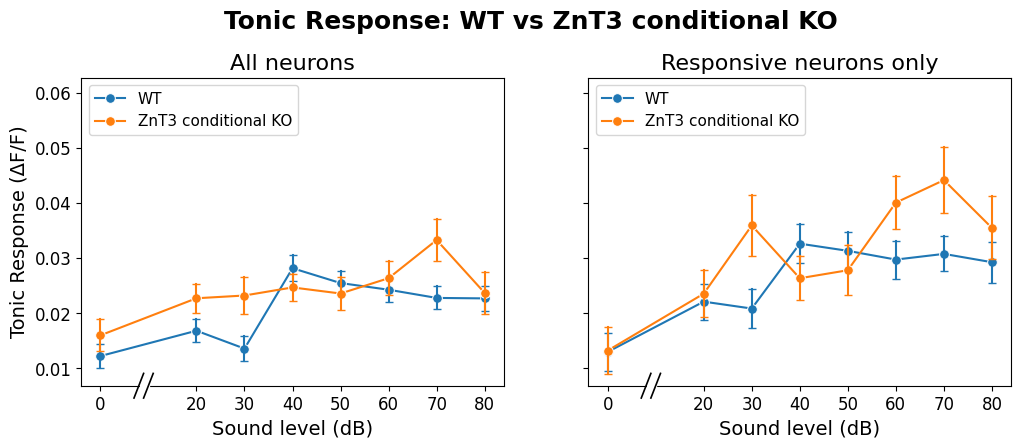

In [704]:
# Plot tonic response amplitudes across sound levels (WT vs conditional ZnT3 KO)

# Get unique sound levels (assuming both genotypes share the same levels)
levels_sorted = sorted(df_resp_WT['dB'].unique())
xpos = np.arange(len(levels_sorted))
xpos[1:] += 1
level2xpos = dict(zip(levels_sorted, xpos))

# Convert to long-format DataFrame: all neurons (tonic)
df_all_WT = pd.DataFrame({
    'Sound level (dB)': df_resp_WT['dB'],
    'Response': df_resp_WT['dFF_avg_tonic']
})
df_all_WT['Genotype'] = 'WT'
df_all_WT['xpos'] = df_all_WT['Sound level (dB)'].map(level2xpos)

df_all_KO = pd.DataFrame({
    'Sound level (dB)': df_resp_ZnT3KO_conditional['dB'],
    'Response': df_resp_ZnT3KO_conditional['dFF_avg_tonic']
})
df_all_KO['Genotype'] = 'ZnT3 conditional KO'
df_all_KO['xpos'] = df_all_KO['Sound level (dB)'].map(level2xpos)

df_all_long = pd.concat([df_all_WT, df_all_KO], ignore_index=True)

# Convert to long-format DataFrame: responsive neurons only
df_resp_WT_only = df_resp_WT[df_resp_WT['responsive_neuron']]
df_resp_KO_only = df_resp_ZnT3KO_conditional[df_resp_ZnT3KO_conditional['responsive_neuron']]

df_grouped_WT = pd.DataFrame({
    'Sound level (dB)': df_resp_WT_only['dB'],
    'Response': df_resp_WT_only['dFF_avg_tonic']
})
df_grouped_WT['Genotype'] = 'WT'
df_grouped_WT['xpos'] = df_grouped_WT['Sound level (dB)'].map(level2xpos)

df_grouped_KO = pd.DataFrame({
    'Sound level (dB)': df_resp_KO_only['dB'],
    'Response': df_resp_KO_only['dFF_avg_tonic']
})
df_grouped_KO['Genotype'] = 'ZnT3 conditional KO'
df_grouped_KO['xpos'] = df_grouped_KO['Sound level (dB)'].map(level2xpos)

df_grouped_long = pd.concat([df_grouped_WT, df_grouped_KO], ignore_index=True)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Left subplot: all neurons
sns.lineplot(data=df_all_long, x='xpos', y='Response', hue='Genotype', 
             errorbar='se', err_style='bars', err_kws={'capsize':3}, marker='o', markersize=7, ax=ax[0])
ax[0].set_title('All neurons', fontsize=16)
ax[0].set_ylabel('Tonic Response (ΔF/F)', fontsize=14)
ax[0].legend(title=None, loc='upper left', fontsize=11)

# Right subplot: responsive neurons only
sns.lineplot(data=df_grouped_long, x='xpos', y='Response', hue='Genotype', 
             errorbar='se', err_style='bars', err_kws={'capsize':3}, marker='o', markersize=7, ax=ax[1])
ax[1].set_title('Responsive neurons only', fontsize=16)
ax[1].legend(title=None, loc='upper left', fontsize=11)

# Format axes
for axn in ax:
    axn.set_xlabel('Sound level (dB)', fontsize=14)
    axn.set_xticks(xpos)
    axn.set_xticklabels(levels_sorted)
    axn.tick_params(axis='both', labelsize=12)

# Increase Y upper limit slightly
ymin, ymax = ax[0].get_ylim()
for axn in ax:
    axn.set_ylim(ymin, ymax*1.2)

# Add axis break slashes between 0 dB and 20 dB
break_x = (xpos[0] + xpos[1]) / 2
for axn in ax:
    axn.plot([break_x-0.1, break_x-0.05], [0, 0], transform=axn.get_xaxis_transform(),
             color='white', linewidth=6, clip_on=False, zorder=10)
    dx, dy = 0.10, 0.04
    kwargs = dict(transform=axn.get_xaxis_transform(), color='k', clip_on=False, linewidth=1.2, zorder=11)
    axn.plot([break_x-dx, break_x+dx], [-dy, +dy], **kwargs)
    axn.plot([break_x-3*dx, break_x-dx], [-dy, +dy], **kwargs)

fig.suptitle('Tonic Response: WT vs ZnT3 conditional KO', fontsize=18, fontweight='bold', y=1.05)
plt.show()

## preZX1 vs postZX1

In [12]:
import joblib
# df_resp_pre = joblib.load('../data/cache/2pResp_ZnT3KO_conditional.joblib')
# df_resp_post = joblib.load('../data/cache/2pResp_ZnT3KO_conditional_postZX1.joblib')

df_resp_pre = joblib.load('../data/cache/2pResp_WT_preZX1.joblib')
df_resp_post = joblib.load('../data/cache/2pResp_WT_postZX1.joblib')

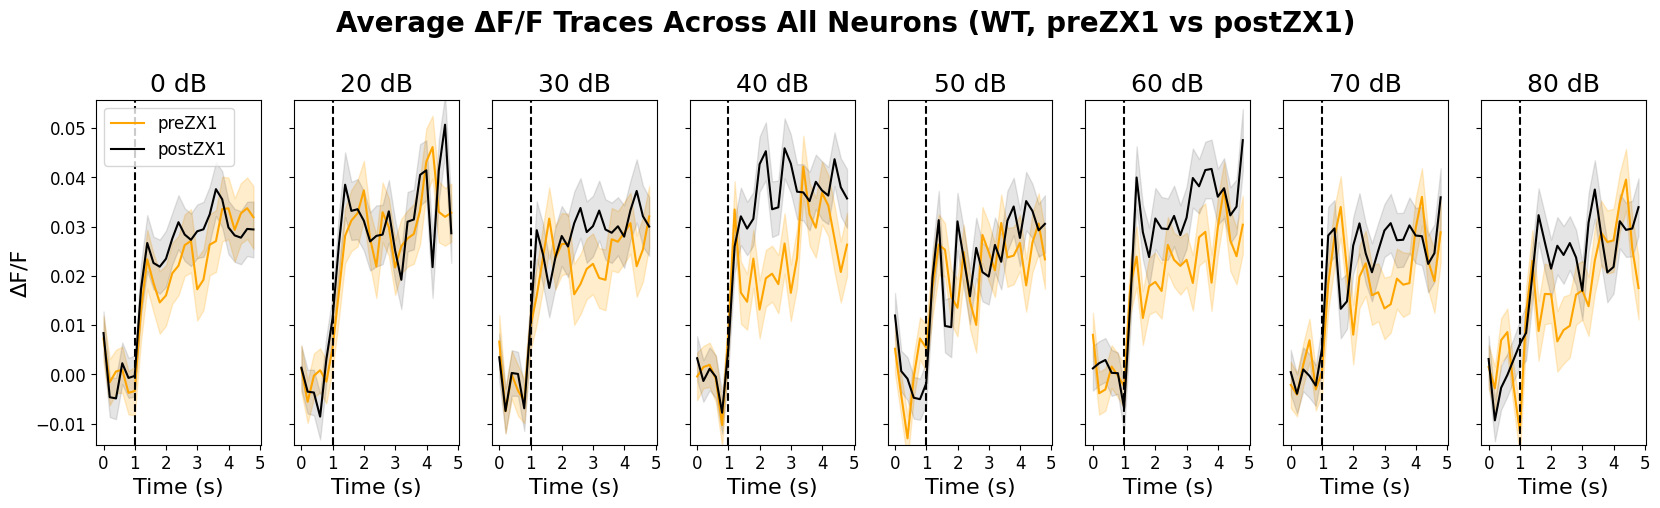

In [13]:
# Plot average dF/F traces across all neurons re sound level (conditional WT, preZX1 vs postZX1)
import numpy as np
import matplotlib.pyplot as plt
import lib.signalProcess as signalProcess

# Get unique sound levels (assuming both genotypes share the same levels)
levels = sorted(df_resp_pre['dB'].unique())

# Compute global ymin / ymax across all sound levels for both genotypes
ymins, ymaxs = [], []
for level in levels:
    # preZX1 traces
    traces_pre = np.stack(df_resp_pre[df_resp_pre['dB'] == level]['dFF_trace'].values)
    avg_pre, _, _ = signalProcess.meanPlusMinusSem(traces_pre, ignoreNaN=True)
    # postZX1 traces
    traces_post = np.stack(df_resp_post[df_resp_post['dB'] == level]['dFF_trace'].values)
    avg_post, _, _ = signalProcess.meanPlusMinusSem(traces_post, ignoreNaN=True)
    
    ymins.append(min(np.nanmin(avg_pre), np.nanmin(avg_post)))
    ymaxs.append(max(np.nanmax(avg_pre), np.nanmax(avg_post)))

ymin, ymax = np.min(ymins) * 1.1, np.max(ymaxs) * 1.1

# Compute common X axis ticks
trace_len_max = max(
    max(len(trace) for trace in df_resp_pre['dFF_trace']),
    max(len(trace) for trace in df_resp_post['dFF_trace'])
)
timeVector_common = np.insert(timeVector[:trace_len_max-1], 0, 0)

fig, ax = plt.subplots(1, len(levels), figsize=(20, 5))
for i, level in enumerate(levels):
    # preZX1 traces
    traces_pre = np.stack(df_resp_pre[df_resp_pre['dB'] == level]['dFF_trace'].values)
    avg_pre, pre_psem, pre_msem = signalProcess.meanPlusMinusSem(traces_pre, ignoreNaN=True)
    # postZX1 traces
    traces_post = np.stack(df_resp_post[df_resp_post['dB'] == level]['dFF_trace'].values)
    avg_post, post_psem, post_msem = signalProcess.meanPlusMinusSem(traces_post, ignoreNaN=True)
    
    # Time vector
    timeVector_seg = np.insert(timeVector[:avg_pre.shape[0]-1], 0, 0)
    
    # Plot preZX1 traces
    ax[i].plot(timeVector_seg, avg_pre, label='preZX1', color='orange')
    ax[i].fill_between(timeVector_seg, pre_psem, pre_msem, alpha=0.2, color='orange')
    
    # Plot postZX1 traces
    ax[i].plot(timeVector_seg, avg_post, label='postZX1', color='k')
    ax[i].fill_between(timeVector_seg, post_psem, post_msem, alpha=0.1, color='k')
    
    ax[i].axvline(x=-t_base[0], color='k', linestyle='--')
    ax[i].set_title(f'{level} dB', fontsize=18)
    ax[i].set_xlabel('Time (s)', fontsize=16)
    ax[i].set_ylim(ymin, ymax)
    ax[i].set_xticks(np.arange(min(timeVector_common), max(timeVector_common) + 1, 1))
    ax[i].tick_params(axis='both', labelsize=12)
    if i == 0:
        ax[i].set_ylabel('ΔF/F', fontsize=16)
        ax[i].legend(fontsize=12, loc='upper left')
    else:
        ax[i].set_yticklabels([])

fig.suptitle('Average ΔF/F Traces Across All Neurons (WT, preZX1 vs postZX1)', fontsize=20, fontweight='bold')
fig.subplots_adjust(top=0.8)

plt.show()

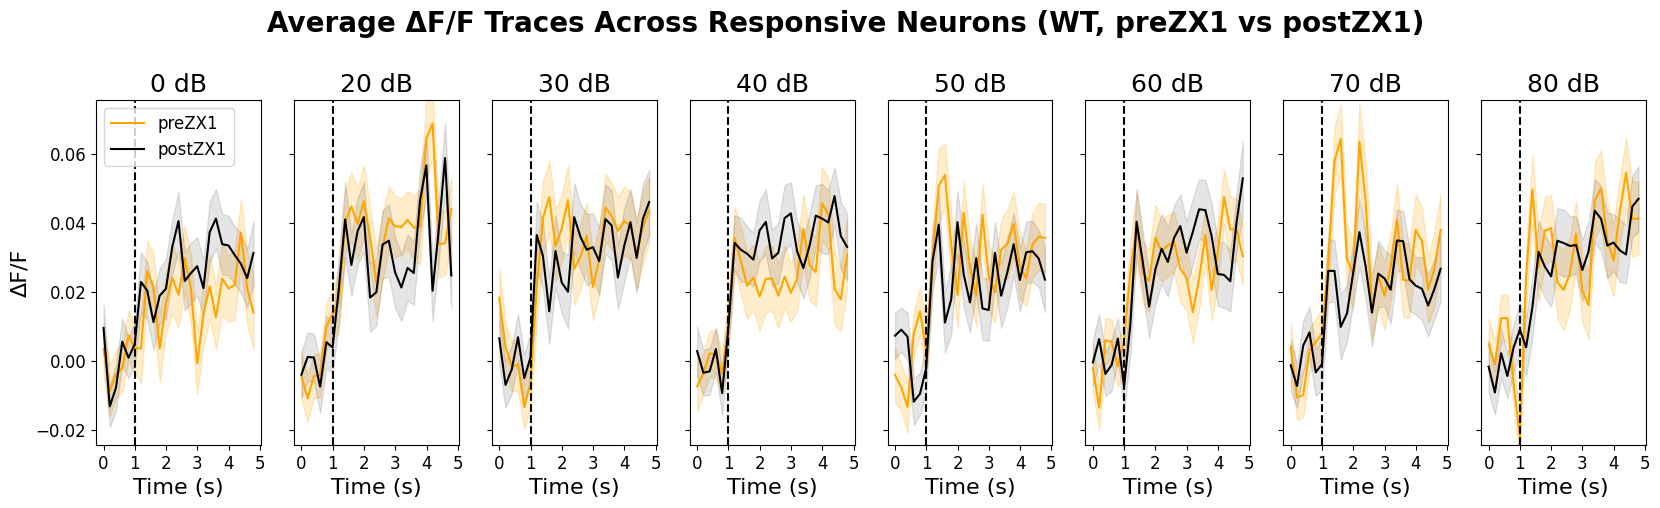

In [15]:
# Plot average dF/F traces across responsive neurons re sound level (conditional WT, preZX1 vs postZX1)

# Get unique sound levels (assuming both genotypes share the same levels)
levels = sorted(df_resp_pre['dB'].unique())

# Compute global ymin / ymax across all sound levels (responsive neurons only)
ymins, ymaxs = [], []
for level in levels:
    # preZX1 responsive neurons
    resp_pre = np.stack(df_resp_pre.loc[(df_resp_pre['dB'] == level) & (df_resp_pre['responsive_neuron']), 'dFF_trace'].values)
    avg_pre, _, _ = signalProcess.meanPlusMinusSem(resp_pre, ignoreNaN=True)
    
    # postZX1 responsive neurons
    resp_post = np.stack(df_resp_post.loc[(df_resp_post['dB'] == level) & (df_resp_post['responsive_neuron']), 'dFF_trace'].values)
    avg_post, _, _ = signalProcess.meanPlusMinusSem(resp_post, ignoreNaN=True)
    
    ymins.append(min(np.nanmin(avg_pre), np.nanmin(avg_post)))
    ymaxs.append(max(np.nanmax(avg_pre), np.nanmax(avg_post)))

ymin, ymax = np.min(ymins) * 1.1, np.max(ymaxs) * 1.1

# Compute common X axis ticks
trace_len_max = max(
    df_resp_pre['dFF_trace'].apply(len).max(),
    df_resp_post['dFF_trace'].apply(len).max()
)
timeVector_common = np.insert(timeVector[:trace_len_max-1], 0, 0)

fig, ax = plt.subplots(1, len(levels), figsize=(20, 5))
for i, level in enumerate(levels):
    # Extract responsive traces for preZX1
    resp_pre = np.stack(df_resp_pre.loc[(df_resp_pre['dB'] == level) & (df_resp_pre['responsive_neuron']), 'dFF_trace'].values)
    avg_pre, psem_pre, msem_pre = signalProcess.meanPlusMinusSem(resp_pre, ignoreNaN=True)
    
    # Extract responsive traces for postZX1
    resp_post = np.stack(df_resp_post.loc[(df_resp_post['dB'] == level) & (df_resp_post['responsive_neuron']), 'dFF_trace'].values)
    avg_post, psem_post, msem_post = signalProcess.meanPlusMinusSem(resp_post, ignoreNaN=True)
    
    # Time vector within display window
    timeVector_seg = np.insert(timeVector[:avg_pre.shape[0]-1], 0, 0)
    
    # Plot pre
    ax[i].plot(timeVector_seg, avg_pre, label='preZX1', color='orange')
    ax[i].fill_between(timeVector_seg, psem_pre, msem_pre, alpha=0.2, color='orange')
    
    # Plot post
    ax[i].plot(timeVector_seg, avg_post, label='postZX1', color='k')
    ax[i].fill_between(timeVector_seg, psem_post, msem_post, alpha=0.1, color='k')
    
    ax[i].axvline(x=-t_base[0], color='k', linestyle='--')
    ax[i].set_title(f'{level} dB', fontsize=18)
    ax[i].set_xlabel('Time (s)', fontsize=16)
    ax[i].set_ylim(ymin, ymax)
    ax[i].set_xticks(np.arange(min(timeVector_common), max(timeVector_common) + 1, 1))
    ax[i].tick_params(axis='both', labelsize=12)
    if i == 0:
        ax[i].set_ylabel('ΔF/F', fontsize=16)
        ax[i].legend(fontsize=12, loc='upper left')
    else:
        ax[i].set_yticklabels([])

fig.suptitle('Average ΔF/F Traces Across Responsive Neurons (WT, preZX1 vs postZX1)', fontsize=20, fontweight='bold')
fig.subplots_adjust(top=0.8)

plt.show()

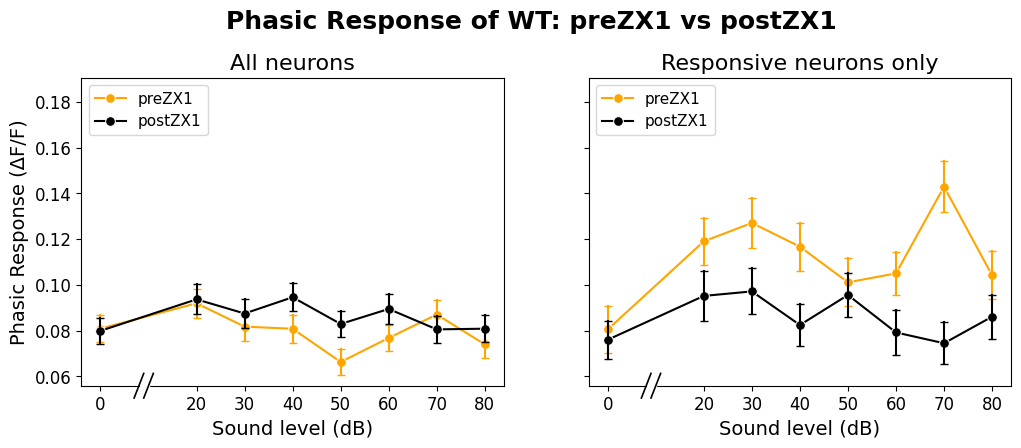

In [16]:
# Plot phasic response amplitudes across sound levels (conditional WT, preZX1 vs postZX1)
import pandas as pd
import seaborn as sns

# Get unique sound levels (assuming both genotypes share the same levels)
levels_sorted = sorted(df_resp_pre['dB'].unique())
xpos = np.arange(len(levels_sorted))
xpos[1:] += 1
level2xpos = dict(zip(levels_sorted, xpos))

# Convert to long-format DataFrame: all neurons
df_all_pre = pd.DataFrame({
    'Sound level (dB)': df_resp_pre['dB'],
    'Response': df_resp_pre['dFF_peak_phasic']
})
df_all_pre['Genotype'] = 'preZX1'
df_all_pre['xpos'] = df_all_pre['Sound level (dB)'].map(level2xpos)

df_all_post = pd.DataFrame({
    'Sound level (dB)': df_resp_post['dB'],
    'Response': df_resp_post['dFF_peak_phasic']
})
df_all_post['Genotype'] = 'postZX1'
df_all_post['xpos'] = df_all_post['Sound level (dB)'].map(level2xpos)

df_all_long = pd.concat([df_all_pre, df_all_post], ignore_index=True)

# Convert to long-format DataFrame: responsive neurons only
df_resp_pre_only = df_resp_pre[df_resp_pre['responsive_neuron']]
df_resp_post_only = df_resp_post[df_resp_post['responsive_neuron']]

df_grouped_pre = pd.DataFrame({
    'Sound level (dB)': df_resp_pre_only['dB'],
    'Response': df_resp_pre_only['dFF_peak_phasic']
})
df_grouped_pre['Genotype'] = 'preZX1'
df_grouped_pre['xpos'] = df_grouped_pre['Sound level (dB)'].map(level2xpos)

df_grouped_post = pd.DataFrame({
    'Sound level (dB)': df_resp_post_only['dB'],
    'Response': df_resp_post_only['dFF_peak_phasic']
})
df_grouped_post['Genotype'] = 'postZX1'
df_grouped_post['xpos'] = df_grouped_post['Sound level (dB)'].map(level2xpos)

df_grouped_long = pd.concat([df_grouped_pre, df_grouped_post], ignore_index=True)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Left subplot: all neurons
sns.lineplot(data=df_all_long, x='xpos', y='Response', hue='Genotype', palette={'preZX1': 'orange', 'postZX1': 'k'},
             errorbar='se', err_style='bars', err_kws={'capsize':3}, marker='o', markersize=7, ax=ax[0])
ax[0].set_title('All neurons', fontsize=16)
ax[0].set_ylabel('Phasic Response (ΔF/F)', fontsize=14)
ax[0].legend(title=None, loc='upper left', fontsize=11)

# Right subplot: responsive neurons only
sns.lineplot(data=df_grouped_long, x='xpos', y='Response', hue='Genotype', palette={'preZX1': 'orange', 'postZX1': 'k'},
             errorbar='se', err_style='bars', err_kws={'capsize':3}, marker='o', markersize=7, ax=ax[1])
ax[1].set_title('Responsive neurons only', fontsize=16)
ax[1].legend(title=None, loc='upper left', fontsize=11)

# Format axes
for axn in ax:
    axn.set_xlabel('Sound level (dB)', fontsize=14)
    axn.set_xticks(xpos)
    axn.set_xticklabels(levels_sorted)
    axn.tick_params(axis='both', labelsize=12)

# Increase Y upper limit slightly
ymin, ymax = ax[0].get_ylim()
for axn in ax:
    axn.set_ylim(ymin, ymax*1.2)

# Add axis break slashes between 0 dB and 20 dB
break_x = (xpos[0] + xpos[1]) / 2
for axn in ax:
    axn.plot([break_x-0.1, break_x-0.05], [0, 0], transform=axn.get_xaxis_transform(),
             color='white', linewidth=6, clip_on=False, zorder=10)
    dx, dy = 0.10, 0.04
    kwargs = dict(transform=axn.get_xaxis_transform(), color='k', clip_on=False, linewidth=1.2, zorder=11)
    axn.plot([break_x-dx, break_x+dx], [-dy, +dy], **kwargs)
    axn.plot([break_x-3*dx, break_x-dx], [-dy, +dy], **kwargs)

fig.suptitle('Phasic Response of WT: preZX1 vs postZX1', fontsize=18, fontweight='bold', y=1.05)
plt.show()

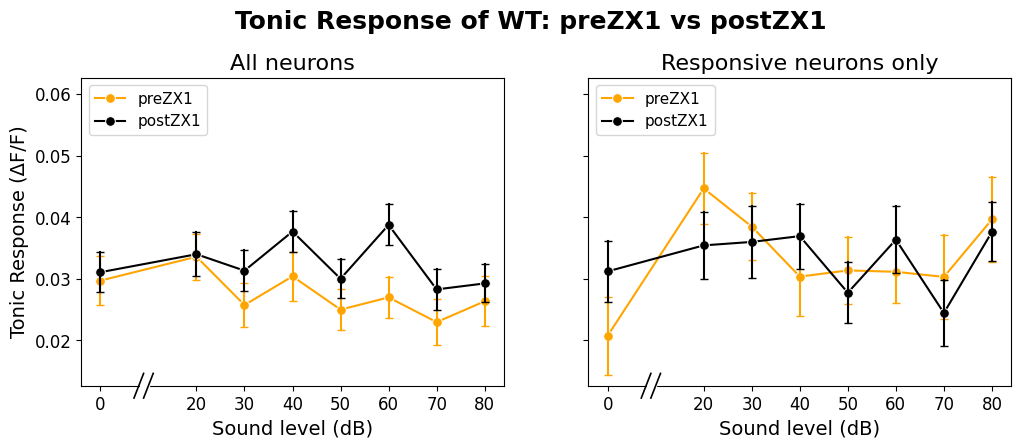

In [17]:
# Plot tonic response amplitudes across sound levels (conditional WT, preZX1 vs postZX1)

# Get unique sound levels (assuming both genotypes share the same levels)
levels_sorted = sorted(df_resp_pre['dB'].unique())
xpos = np.arange(len(levels_sorted))
xpos[1:] += 1
level2xpos = dict(zip(levels_sorted, xpos))

# Convert to long-format DataFrame: all neurons (tonic)
df_all_pre = pd.DataFrame({
    'Sound level (dB)': df_resp_pre['dB'],
    'Response': df_resp_pre['dFF_avg_tonic']
})
df_all_pre['Genotype'] = 'preZX1'
df_all_pre['xpos'] = df_all_pre['Sound level (dB)'].map(level2xpos)

df_all_post = pd.DataFrame({
    'Sound level (dB)': df_resp_post['dB'],
    'Response': df_resp_post['dFF_avg_tonic']
})
df_all_post['Genotype'] = 'postZX1'
df_all_post['xpos'] = df_all_post['Sound level (dB)'].map(level2xpos)

df_all_long = pd.concat([df_all_pre, df_all_post], ignore_index=True)

# Convert to long-format DataFrame: responsive neurons only
df_resp_pre_only = df_resp_pre[df_resp_pre['responsive_neuron']]
df_resp_post_only = df_resp_post[df_resp_post['responsive_neuron']]

df_grouped_pre = pd.DataFrame({
    'Sound level (dB)': df_resp_pre_only['dB'],
    'Response': df_resp_pre_only['dFF_avg_tonic']
})
df_grouped_pre['Genotype'] = 'preZX1'
df_grouped_pre['xpos'] = df_grouped_pre['Sound level (dB)'].map(level2xpos)

df_grouped_post = pd.DataFrame({
    'Sound level (dB)': df_resp_post_only['dB'],
    'Response': df_resp_post_only['dFF_avg_tonic']
})
df_grouped_post['Genotype'] = 'postZX1'
df_grouped_post['xpos'] = df_grouped_post['Sound level (dB)'].map(level2xpos)

df_grouped_long = pd.concat([df_grouped_pre, df_grouped_post], ignore_index=True)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Left subplot: all neurons
sns.lineplot(data=df_all_long, x='xpos', y='Response', hue='Genotype', palette={'preZX1': 'orange', 'postZX1': 'k'},
             errorbar='se', err_style='bars', err_kws={'capsize':3}, marker='o', markersize=7, ax=ax[0])
ax[0].set_title('All neurons', fontsize=16)
ax[0].set_ylabel('Tonic Response (ΔF/F)', fontsize=14)
ax[0].legend(title=None, loc='upper left', fontsize=11)

# Right subplot: responsive neurons only
sns.lineplot(data=df_grouped_long, x='xpos', y='Response', hue='Genotype', palette={'preZX1': 'orange', 'postZX1': 'k'},
             errorbar='se', err_style='bars', err_kws={'capsize':3}, marker='o', markersize=7, ax=ax[1])
ax[1].set_title('Responsive neurons only', fontsize=16)
ax[1].legend(title=None, loc='upper left', fontsize=11)

# Format axes
for axn in ax:
    axn.set_xlabel('Sound level (dB)', fontsize=14)
    axn.set_xticks(xpos)
    axn.set_xticklabels(levels_sorted)
    axn.tick_params(axis='both', labelsize=12)

# Increase Y upper limit slightly
ymin, ymax = ax[0].get_ylim()
for axn in ax:
    axn.set_ylim(ymin, ymax*1.2)

# Add axis break slashes between 0 dB and 20 dB
break_x = (xpos[0] + xpos[1]) / 2
for axn in ax:
    axn.plot([break_x-0.1, break_x-0.05], [0, 0], transform=axn.get_xaxis_transform(),
             color='white', linewidth=6, clip_on=False, zorder=10)
    dx, dy = 0.10, 0.04
    kwargs = dict(transform=axn.get_xaxis_transform(), color='k', clip_on=False, linewidth=1.2, zorder=11)
    axn.plot([break_x-dx, break_x+dx], [-dy, +dy], **kwargs)
    axn.plot([break_x-3*dx, break_x-dx], [-dy, +dy], **kwargs)

fig.suptitle('Tonic Response of WT: preZX1 vs postZX1', fontsize=18, fontweight='bold', y=1.05)
plt.show()

## Broadband train (old script)

In [13]:
# resp2pPaths = [r"C:\Data\Shengjie Data\Training_GCaMP8m\Training03042025\2photon\AA0001\GCaMP8m_Training03042025_BB_2SD_CTRL_Responses.mat"]
# resp2pPaths = [r"C:\Data\Manoj Data\Region03\GRISZ05_03_BB_2SD_Pre_SE_SYanalysis_Responses.mat"]

# 2 SD criterion, response window 0.3 sec to 1.3 sec after sound onset
resp2pPaths = [
    # r"C:\Data\Manoj Data\2photon\GRISZ02\GRISZ02_BB_2SD_Pre_SE_SYanalysis_Responses.mat", 
    # r"C:\Data\Manoj Data\2photon\GRISZ03\Region01\GRISZ03_01_BB_2SD_Pre_SE_SYanalysis_Responses.mat", 
    # r"C:\Data\Manoj Data\2photon\GRISZ05\Region01\GRISZ05_01_BB_2SD_Pre_SE_SYanalysis_Responses.mat", 
    # r"C:\Data\Manoj Data\2photon\GRISZ05\Region03\GRISZ05_03_BB_2SD_Pre_SE_SYanalysis_Responses.mat", 
    # r"C:\Data\Shengjie Data\TLB10-GRISZ\03242025\AA0001\Control_2photon_broadband_14trains_MKprotocol\AA0001\GRISZ_20250324_BB_2SD_CTRL_Responses.mat", 
    # r"C:\Data\Shengjie Data\TLB10-GRISZ\03262025\AA0001\Control_2photon_broadband_14trains_MKprotocol\AA0001\GRISZ_20250326_BB_2SD_CTRL_Responses.mat", 
    # r"C:\Data\Shengjie Data\TLB10-GRISZ\05052025\AA0001\Control_2photon_broadband_8trains_MKprotocol_preWidefield_preZX1\AA0001\GRISZ_20250505_BB_2SD_CTRL_Responses.mat", 
    # r"C:\Data\Shengjie Data\TLB10-GRISZ\05282025\AA0001\Control_2photon_broadband_11trains_MKprotocol\AA0001\GRISZ_20250528_BB_2SD_CTRL_Responses.mat", 
    # r"C:\Data\Shengjie Data\Oddball_TLB10-GIRSZ\20250917\AA0001\Control_2photon_broadband\AA0001\GRISZ_20250917_BB_2SD_CTRL_Responses.mat", 
    # r"C:\Data\Shengjie Data\TLB10-GRISZ\09222025\AA0001\Control_2photon_broadband_11trains\AA0001\GRISZ_20250922_BB_2SD_CTRL_Responses.mat", 
    # r"C:\Data\Shengjie Data\TLB10-GRISZ\09242025\AA0001\Control_2photon_broadband_5trains\AA0001\GRISZ_20250924_BB_2SD_CTRL_Responses.mat", 
    r"C:\Data\Shengjie Data\TLB10-GRISZ\11252025\AA0001\Broadband_20_80dB_400msStimLength_13trials\AA0001\GRISZ_20251125_BB_2SD_CTRL_Responses.mat", 
    r"C:\Data\Shengjie Data\TLB10-GRISZ\11262025\AA0001\Broadband_20_80dB_400msStimLength_14trials\AA0001\GRISZ_20251126_BB_2SD_CTRL_Responses.mat", 
    # r"C:\Data\Shengjie Data\TLB10-GRISZ\20260129\AA0001\GRISZ\AA0001\GRISZ_20260129_BB_2SD_CTRL_Responses.mat"
]

# 3 SD criterion, response window 0.3 sec to 2.0 sec after sound onset
# resp2pPaths = [
    # r"C:\Data\Manoj Data\2photon\GRISZ02\GRISZ02_BB_3SD_Pre_SE_SYanalysis_Responses.mat", 
    # r"C:\Data\Manoj Data\2photon\GRISZ03\Region01\GRISZ03_01_BB_3SD_Pre_SE_SYanalysis_Responses.mat", 
    # r"C:\Data\Manoj Data\2photon\GRISZ05\Region01\GRISZ05_01_BB_3SD_Pre_SE_SYanalysis_Responses.mat", 
    # r"C:\Data\Manoj Data\2photon\GRISZ05\Region03\GRISZ05_03_BB_3SD_Pre_SE_SYanalysis_Responses.mat", 
    # r"C:\Data\Shengjie Data\TLB10-GRISZ\03242025\AA0001\Control_2photon_broadband_14trains_MKprotocol\AA0001\GRISZ_20250324_BB_3SD_CTRL_Responses.mat", 
    # r"C:\Data\Shengjie Data\TLB10-GRISZ\03262025\AA0001\Control_2photon_broadband_14trains_MKprotocol\AA0001\GRISZ_20250326_BB_3SD_CTRL_Responses.mat", 
    # r"C:\Data\Shengjie Data\TLB10-GRISZ\05052025\AA0001\Control_2photon_broadband_8trains_MKprotocol_preWidefield_preZX1\AA0001\GRISZ_20250505_BB_3SD_CTRL_Responses.mat", 
    # r"C:\Data\Shengjie Data\TLB10-GRISZ\05282025\AA0001\Control_2photon_broadband_11trains_MKprotocol\AA0001\GRISZ_20250528_BB_3SD_CTRL_Responses.mat", 
    # r"C:\Data\Shengjie Data\Oddball_TLB10-GIRSZ\20250917\AA0001\Control_2photon_broadband\AA0001\GRISZ_20250917_BB_3SD_CTRL_Responses.mat", 
    # r"C:\Data\Shengjie Data\TLB10-GRISZ\09222025\AA0001\Control_2photon_broadband_11trains\AA0001\GRISZ_20250922_BB_3SD_CTRL_Responses.mat", 
    # r"C:\Data\Shengjie Data\TLB10-GRISZ\09242025\AA0001\Control_2photon_broadband_5trains\AA0001\GRISZ_20250924_BB_3SD_CTRL_Responses.mat", 
    # r"C:\Data\Shengjie Data\TLB10-GRISZ\11252025\AA0001\Broadband_20_80dB_400msStimLength_13trials\AA0001\GRISZ_20251125_BB_3SD_CTRL_Responses.mat", 
    # r"C:\Data\Shengjie Data\TLB10-GRISZ\11262025\AA0001\Broadband_20_80dB_400msStimLength_14trials\AA0001\GRISZ_20251126_BB_3SD_CTRL_Responses.mat", 
    # r"C:\Data\Shengjie Data\TLB10-GRISZ\20260129\AA0001\GRISZ\AA0001\GRISZ_20260129_BB_3SD_CTRL_Responses.mat"
# ]

In [14]:
import numpy as np
import lib.metadataProcess as metadataProcess
import warnings

# Initialize lists to store data from each file
levelLabels_temp, timeVectors_temp, respIndices_temp, dFFtraces_temp = [], [], [], []

# Track neuron count offset for cumulative indexing
neuron_offset = 0

for path in resp2pPaths:
    levelLabel, timeVector, respIndex, dFFtraces = metadataProcess.getDFFtraces(path)

    levelLabels_temp.append(levelLabel)
    timeVectors_temp.append(timeVector)
    dFFtraces_temp.append(np.mean(dFFtraces, axis=2))  # Average across trials

    # Offset responsive indices to align with concatenated dataset
    respIndices_temp.append([i + neuron_offset for i in respIndex])

    # Update offset by neuron count in this animal
    neuron_offset += dFFtraces.shape[0]

# Check whether all timeVectors are identical
for i in range(1, len(timeVectors_temp)):
    if not np.array_equal(timeVectors_temp[i], timeVectors_temp[0]):
        warnings.warn(f"Mismatch detected in 'timeVector' between file 0 and file {i}.")

# If time vectors are of different lengths, truncate to the shortest
if not all(len(tv) == len(timeVectors_temp[0]) for tv in timeVectors_temp):
    warnings.warn("Time vectors have different lengths; truncating to shortest length.")
    min_length = min(len(tv) for tv in timeVectors_temp)
    timeVectors_temp = [tv[:min_length] for tv in timeVectors_temp]
    dFFtraces_temp = [dt[:, :, :min_length] for dt in dFFtraces_temp]
else:
    print("All time vectors are identical in length.")
    min_length = None  # Store whether truncation was applied

# Check whether all levelLabels are identical
for i in range(1, len(levelLabels_temp)):
    if levelLabels_temp[i] != levelLabels_temp[0]:
        raise ValueError(f"Mismatch detected in 'levelLabel' between file 0 and file {i}.")

# Use the first file's levelLabel and timeVector
levelLabels = levelLabels_temp[0]
timeVectors = timeVectors_temp[0]

# Concatenate all datasets across animals
dFFtraces = np.concatenate(dFFtraces_temp, axis=0)
respIndices = np.concatenate(respIndices_temp)
nonRespIndices = np.array([x for x in range(dFFtraces.shape[0]) if x not in respIndices])

print(f"Combined dataset shape: {dFFtraces.shape}")
print(f"Responsive neurons: {len(respIndices)} / {dFFtraces.shape[0]}")

Extracted dF/F traces [neuronNumber, soundLevel, traceNumber, frame] of shape: (125, 7, 12, 25)
Extracted dF/F traces [neuronNumber, soundLevel, traceNumber, frame] of shape: (154, 7, 14, 25)
All time vectors are identical in length.
Combined dataset shape: (279, 7, 25)
Responsive neurons: 120 / 279


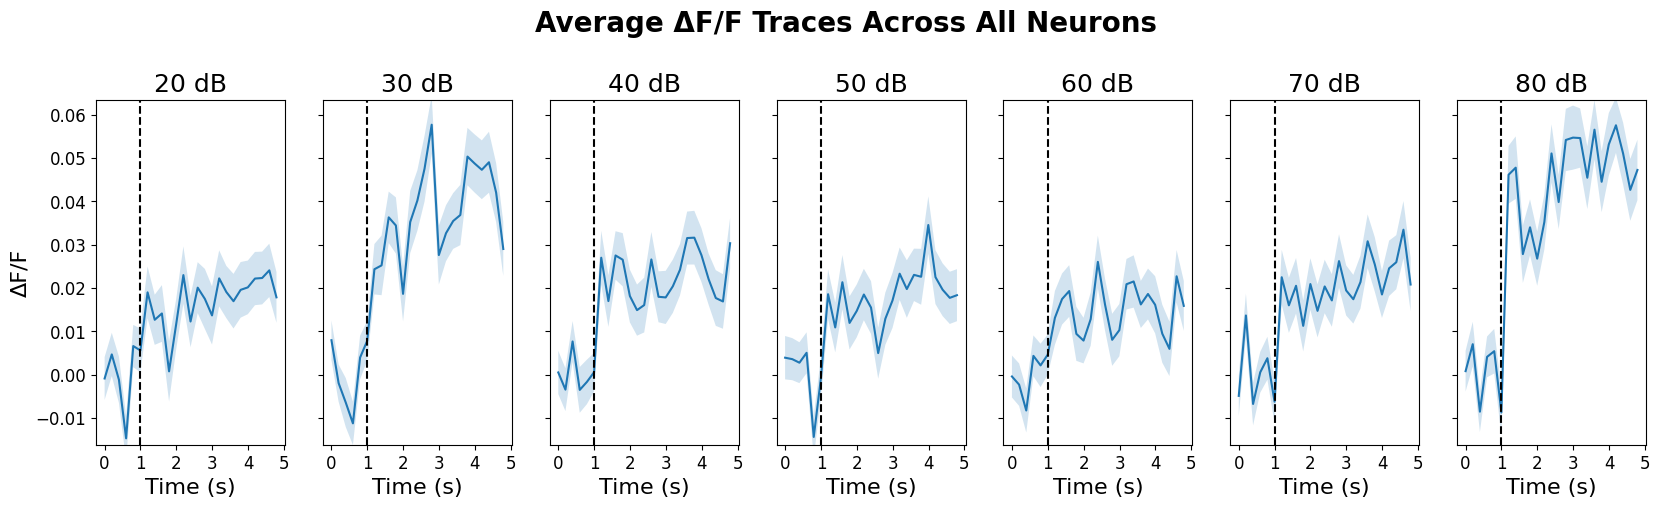

In [15]:
# All neurons

import matplotlib.pyplot as plt
import lib.signalProcess as signalProcess

# Average traces across all neurons
avg_traces, traces_psem, traces_msem = signalProcess.meanPlusMinusSem(dFFtraces, ignoreNaN=True)  # Handle NaNs if any
ymin, ymax = np.nanmin(avg_traces) * 1.1, np.nanmax(avg_traces) * 1.1

fig, ax = plt.subplots(1, len(levelLabels), figsize=(20, 5))
for i, level in enumerate(levelLabels):
    ax[i].plot(timeVectors, avg_traces[i, :])
    ax[i].fill_between(timeVectors, traces_psem[i, :], traces_msem[i, :], alpha=0.2)
    ax[i].axvline(x=1, color='k', linestyle='--')
    ax[i].set_title(f'{level} dB', fontsize=18)
    ax[i].set_xlabel('Time (s)', fontsize=16)
    ax[i].set_ylim(ymin, ymax)
    ax[i].set_xticks(np.arange(min(timeVectors), max(timeVectors) + 1, 1))
    ax[i].tick_params(axis='both', labelsize=12)
    if i == 0:
        ax[i].set_ylabel('ΔF/F', fontsize=16)
    else:
        ax[i].set_yticklabels([])
fig.suptitle('Average ΔF/F Traces Across All Neurons', fontsize=20, fontweight='bold')
fig.subplots_adjust(top=0.8)

plt.show()

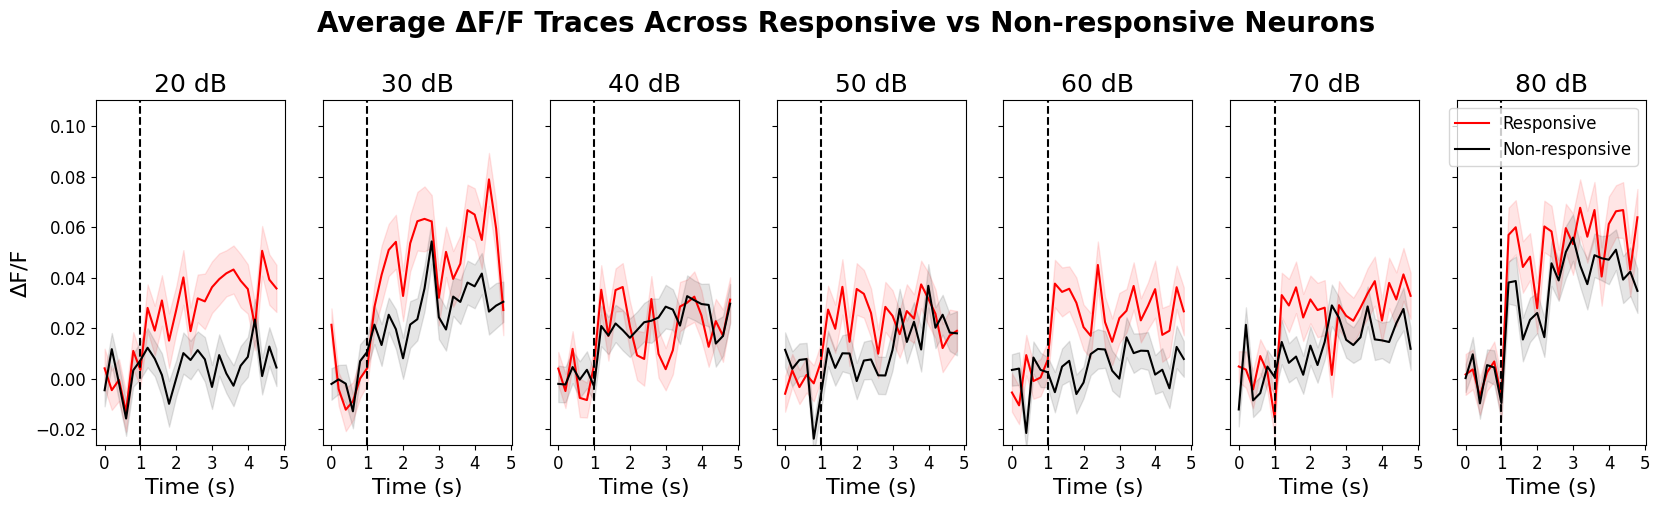

In [ ]:
# Responsive vs non-responsive neurons

avg_resp_traces, resp_traces_psem, resp_traces_msem = signalProcess.meanPlusMinusSem(dFFtraces[respIndices, :, :], ignoreNaN=True)  # Handle NaNs if any
avg_nonResp_traces, nonResp_traces_psem, nonResp_traces_msem = signalProcess.meanPlusMinusSem(dFFtraces[nonRespIndices, :, :], ignoreNaN=True)  # Handle NaNs if any

ymin = min(np.nanmin(avg_resp_traces), np.nanmin(avg_nonResp_traces)) * 1.1
ymax = max(np.nanmax(avg_resp_traces), np.nanmax(avg_nonResp_traces)) * 1.4

fig, ax = plt.subplots(1, len(levelLabels), figsize=(20, 5))
for i, level in enumerate(levelLabels):
    ax[i].plot(timeVectors, avg_resp_traces[i, :], color='r', label='Responsive')
    ax[i].fill_between(timeVectors, resp_traces_psem[i, :], resp_traces_msem[i, :], color='r', alpha=0.1)
    ax[i].plot(timeVectors, avg_nonResp_traces[i, :], color='k', label='Non-responsive')
    ax[i].fill_between(timeVectors, nonResp_traces_psem[i, :], nonResp_traces_msem[i, :], color='k', alpha=0.1)
    ax[i].axvline(x=1, color='k', linestyle='--')
    ax[i].set_title(f'{level} dB', fontsize=18)
    ax[i].set_xlabel('Time (s)', fontsize=16)
    ax[i].set_ylim(ymin, ymax)
    ax[i].set_xticks(np.arange(min(timeVectors), max(timeVectors) + 1, 1))
    ax[i].tick_params(axis='both', labelsize=12)
    if i == 0:
        ax[i].set_ylabel('ΔF/F', fontsize=16)
    else:
        ax[i].set_yticklabels([])
    if i == len(levelLabels) - 1:
        ax[i].legend(fontsize=12, loc='upper right')
fig.suptitle('Average ΔF/F Traces Across Responsive vs Non-responsive Neurons', fontsize=20, fontweight='bold')
fig.subplots_adjust(top=0.8)

plt.show()

## Single broadband sound

In [2257]:
import lib.metadataProcess as metadataProcess

resp2pPaths = [r"C:\Data\Shengjie Data\TLB10-GRISZ\20260216\AA0001\AA0001\GRISZ_20260216_BB_CTRL_allTrials_rawFluoWholeTraces.mat"]
levelOrder, timeVector, soundOnsets, rawFluoWholeTraces = metadataProcess.getRawFluoWholeTraces(resp2pPaths[0])

Extracted raw whole fluorescence traces [traceNumber, neuronNumber, frame] of shape: (33, 151, 260)


C:\Users\SHY200\AppData\Local\Temp\ipykernel_12972\1328005171.py:10: RuntimeWarning: Mean of empty slice
  dFFwholeTraces_trialAvg = np.nanmean(dFFwholeTraces, axis=0)  # of shape [neuronNumber, frame]


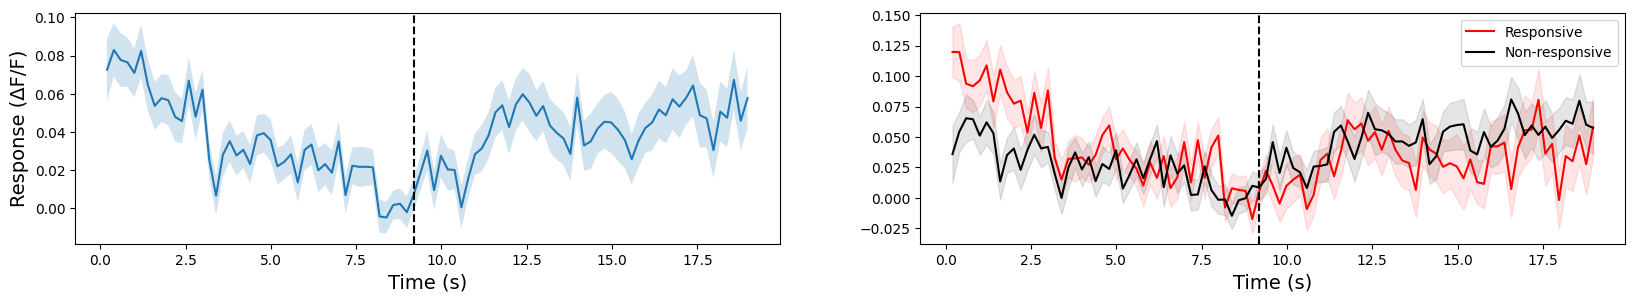

In [2263]:
import lib.signalProcess as signalProcess
import matplotlib.pyplot as plt
import numpy as np

rawFluoWholeTraces_80dB = rawFluoWholeTraces[18:24, :, :]
# rawFluoWholeTraces_80dB = np.delete(rawFluoWholeTraces_80dB, 3, axis=0) # Exclude trial 3 with motion artifacts
soundOnset = timeVector[45]  # 6 + 3 sec sound delay
dFFwholeTraces = signalProcess.dFFcalc(rawFluoWholeTraces_80dB, t = timeVector, 
                                       t_base = (soundOnset-1, soundOnset), t_resp = (soundOnset+0.3, soundOnset+1.3))[0] # of shape [traceNumber, neuronNumber, frame]
dFFwholeTraces_trialAvg = np.nanmean(dFFwholeTraces, axis=0)  # of shape [neuronNumber, frame]

# Average traces across all neurons and responsive vs non-responsive neurons
avg_traces, traces_psem, traces_msem = signalProcess.meanPlusMinusSem(dFFwholeTraces_trialAvg, ignoreNaN=True)  # Handle NaNs if any
avg_resp_traces, resp_traces_psem, resp_traces_msem = signalProcess.meanPlusMinusSem(dFFwholeTraces_trialAvg[respIndices, :], ignoreNaN=True)
avg_nonResp_traces, nonResp_traces_psem, nonResp_traces_msem = signalProcess.meanPlusMinusSem(dFFwholeTraces_trialAvg[nonRespIndices, :], ignoreNaN=True)

fig, ax = plt.subplots(1, 2, figsize=(20, 3))
ax[0].plot(timeVector, avg_traces)
ax[0].fill_between(timeVector, traces_msem, traces_psem, alpha=0.2)
ax[0].axvline(x=soundOnset, color='k', linestyle='--')
ax[0].set_xlabel('Time (s)', fontsize=14)
ax[0].set_ylabel('Response (ΔF/F)', fontsize=14)
# ax[0].set_title('All neurons', fontsize=16, fontweight='bold')

ax[1].plot(timeVector, avg_resp_traces, color='r', label='Responsive')
ax[1].fill_between(timeVector, resp_traces_msem, resp_traces_psem, color='r', alpha=0.1)
ax[1].plot(timeVector, avg_nonResp_traces, color='k', label='Non-responsive')
ax[1].fill_between(timeVector, nonResp_traces_msem, nonResp_traces_psem, color='k', alpha=0.1)
ax[1].axvline(x=soundOnset, color='k', linestyle='--')
ax[1].set_xlabel('Time (s)', fontsize=14)
ax[1].legend(loc='upper right', fontsize=10)
# ax[1].set_title('Responsive vs non-responsive neurons', fontsize=16, fontweight='bold')

plt.show()

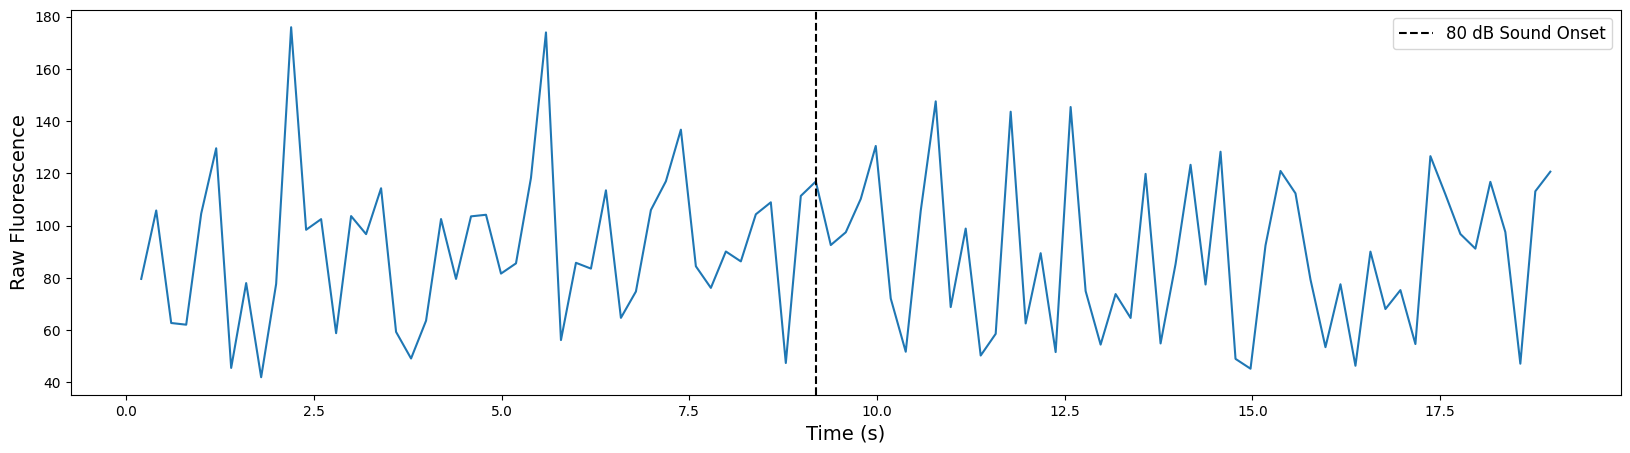

In [2052]:
fig, ax = plt.subplots(figsize=(20, 5))
# ax.plot(timeVector, dFFwholeTraces_trialAvg[25, :]) # Movements occur in neurons 20-27 (lasts only one frame)
ax.plot(timeVector, rawFluoWholeTraces_80dB[3, 25, :]) # Movements occur only in trial indexed 3
ax.axvline(x=soundOnset, color='k', linestyle='--', label='80 dB Sound Onset')
ax.set_xlabel('Time (s)', fontsize=14)
ax.set_ylabel('Raw Fluorescence', fontsize=14)
ax.legend(loc='upper right', fontsize=12)
plt.show()

C:\Users\SHY200\AppData\Local\Temp\ipykernel_12972\3068963315.py:8: RuntimeWarning: Mean of empty slice
  avg_traces, traces_psem, traces_msem = signalProcess.meanPlusMinusSem(np.nanmean(rawFluoWholeTraces_80dB, axis=0), ignoreNaN=True)  # Handle NaNs if any


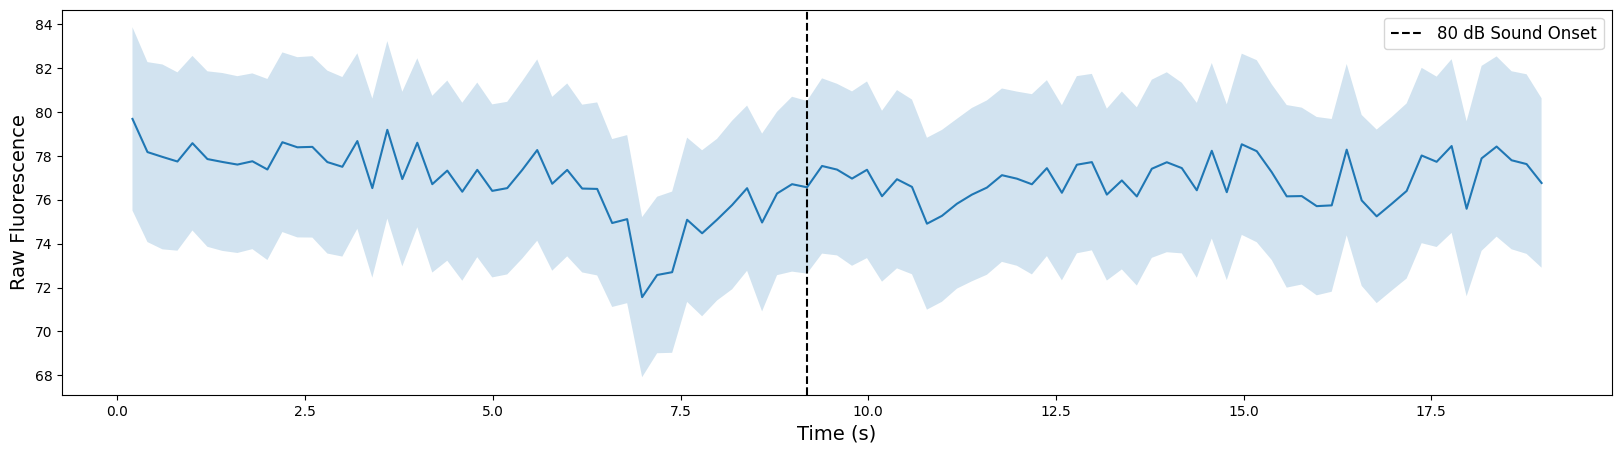

In [2056]:
import matplotlib.pyplot as plt

rawFluoWholeTraces_80dB = rawFluoWholeTraces[:6, :, :]
rawFluoWholeTraces_80dB = np.delete(rawFluoWholeTraces_80dB, 3, axis=0) # Exclude trial 3 with motion artifacts
soundOnset = timeVector[45]

# Average traces across all neurons
avg_traces, traces_psem, traces_msem = signalProcess.meanPlusMinusSem(np.nanmean(rawFluoWholeTraces_80dB, axis=0), ignoreNaN=True)  # Handle NaNs if any

fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(timeVector, avg_traces)
ax.fill_between(timeVector, traces_msem, traces_psem, alpha=0.2)
ax.axvline(x=soundOnset, color='k', linestyle='--', label='80 dB Sound Onset')
ax.set_xlabel('Time (s)', fontsize=14)
ax.set_ylabel('Raw Fluorescence', fontsize=14)
ax.legend(loc='upper right', fontsize=12)

plt.show()

## Quantify average phasic and tonic response amplitudes (old script)

In [598]:
# Apply low-pass Butterworth filter on individual traces and reprocess data

cutoff_freq = 2  # Cutoff frequency (Hz). If None, no filtering is applied.
t_base = [0, 1]  # Baseline time window (s)
t_resp_phasic = [1.3, 3.0]  # Phasic response time window (s)
t_resp_tonic = [3.0, 5.0]  # Tonic response time window (s)
convert_nonRespLevel_toZero = False  # Whether to convert phasic peak responses at non-responsive sound levels to 0 (To-do)

# Initialize lists to store data from each file
dFFtraces_filtered_temp = []

for path in resp2pPaths:
    dFFtraces = metadataProcess.getDFFtraces(path)[3]  # of shape [neuronNumber, soundLevel, traceNumber, frame]
    
    # Apply low-pass filter to each trace as specified (in 2-photon, sample freq is 5 Hz)
    dFFtraces = signalProcess.butterFilter(dFFtraces, sample_freq=5, cutoff_freq=cutoff_freq) if cutoff_freq else dFFtraces

    dFFtraces_filtered_temp.append(np.mean(dFFtraces, axis=2))  # Average across trials

# If time vectors are of different lengths, truncate to the shortest (based on previously stored check)
dFFtraces_filtered_temp = [dt[:, :, :min_length] for dt in dFFtraces_filtered_temp] if min_length else dFFtraces_filtered_temp

# Concatenate all datasets across animals
dFFtraces_filtered = np.concatenate(dFFtraces_filtered_temp, axis=0)

print(f"Combined dataset shape: {dFFtraces_filtered.shape}")

Extracted dF/F traces [neuronNumber, soundLevel, traceNumber, frame] of shape: (103, 7, 14, 25)
Extracted dF/F traces [neuronNumber, soundLevel, traceNumber, frame] of shape: (123, 7, 14, 25)
Extracted dF/F traces [neuronNumber, soundLevel, traceNumber, frame] of shape: (107, 7, 8, 25)
Extracted dF/F traces [neuronNumber, soundLevel, traceNumber, frame] of shape: (108, 7, 11, 25)
Extracted dF/F traces [neuronNumber, soundLevel, traceNumber, frame] of shape: (146, 7, 11, 25)
Extracted dF/F traces [neuronNumber, soundLevel, traceNumber, frame] of shape: (118, 7, 11, 25)
Extracted dF/F traces [neuronNumber, soundLevel, traceNumber, frame] of shape: (117, 7, 5, 25)
Extracted dF/F traces [neuronNumber, soundLevel, traceNumber, frame] of shape: (125, 7, 12, 25)
Extracted dF/F traces [neuronNumber, soundLevel, traceNumber, frame] of shape: (154, 7, 14, 25)
Extracted dF/F traces [neuronNumber, soundLevel, traceNumber, frame] of shape: (142, 7, 11, 25)
Combined dataset shape: (1243, 7, 25)


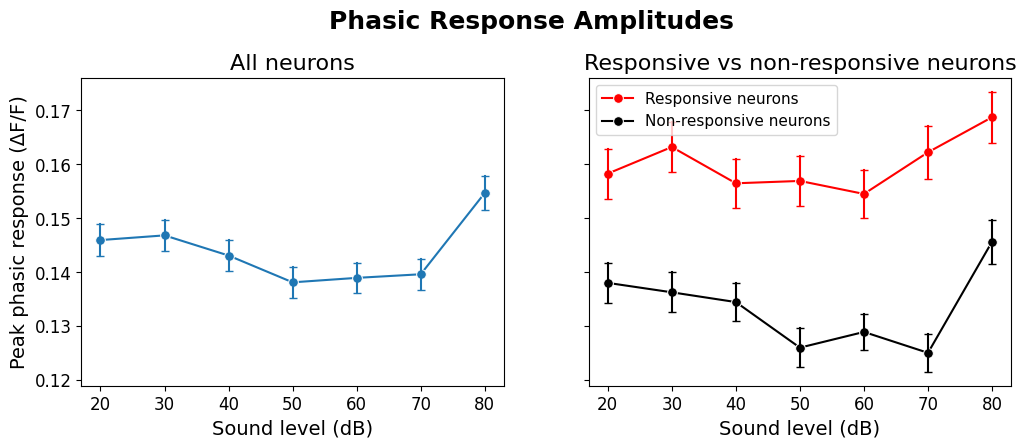

In [599]:
# Quantify average phasic response amplitudes and plot

import seaborn as sns
import pandas as pd

palette = {'Responsive neurons': 'r', 
           'Non-responsive neurons': 'k'}

# Calculate peak phasic responses
peakResp_phasic = signalProcess.getBaseResp(dFFtraces_filtered, timeVectors, t_base=t_base, t_resp=t_resp_phasic)[1]  # of shape [neuronNumber, soundLevel]

# All neurons (for ax[0])
df_phasic_all = pd.DataFrame(peakResp_phasic, columns=levelLabels
                             ).melt(var_name='Sound level (dB)', value_name='Response')

# Responsive vs Non-responsive neurons (for ax[1])
df_phasic_grouped = pd.DataFrame(peakResp_phasic, columns=levelLabels)
df_phasic_grouped['neuron_idx'] = np.arange(df_phasic_grouped.shape[0])

df_phasic_grouped['Group'] = ''
df_phasic_grouped.loc[df_phasic_grouped['neuron_idx'].isin(respIndices), 'Group'] = 'Responsive neurons'
df_phasic_grouped.loc[df_phasic_grouped['neuron_idx'].isin(nonRespIndices), 'Group'] = 'Non-responsive neurons'

df_phasic_grouped_long = df_phasic_grouped.melt(
    id_vars=['neuron_idx', 'Group'],
    var_name='Sound level (dB)',
    value_name='Response'
)

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# ax[0]: all neurons
sns.lineplot(data=df_phasic_all, x='Sound level (dB)', y='Response', errorbar='se', 
             err_style='bars', err_kws={'capsize': 3}, marker='o', markersize=7, ax=ax[0])

ax[0].set_title('All neurons', fontsize=16)
ax[0].set_ylabel('Peak phasic response (ΔF/F)', fontsize=14)

# ax[1]: responsive vs non-responsive
sns.lineplot(data=df_phasic_grouped_long, x='Sound level (dB)', y='Response', hue='Group', 
             hue_order=['Responsive neurons', 'Non-responsive neurons'], palette=palette, 
             errorbar='se', err_style='bars', err_kws={'capsize': 3}, marker='o', markersize=7, ax=ax[1])

ax[1].set_title('Responsive vs non-responsive neurons', fontsize=16)
ax[1].legend(title=None, loc='upper left', fontsize=11)

for axn in ax:
    axn.set_xlabel('Sound level (dB)', fontsize=14)
    axn.tick_params(axis='both', labelsize=12)

fig.suptitle('Phasic Response Amplitudes', fontsize=18, fontweight='bold', y=1.05)
plt.show()

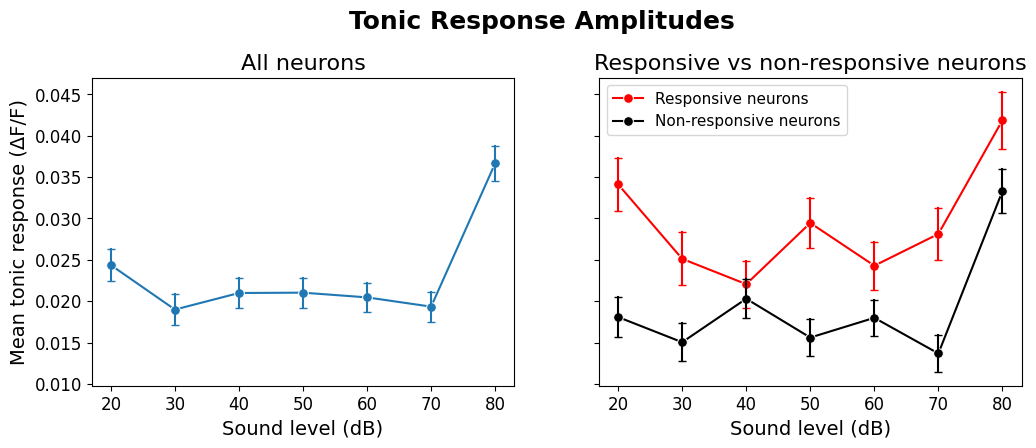

In [600]:
# Quantify average tonic response amplitudes and plot

import seaborn as sns
import pandas as pd

palette = {'Responsive neurons': 'r', 
           'Non-responsive neurons': 'k'}

# Calculate mean tonic responses within 2-4 sec after sound onset
meanResp_tonic = signalProcess.getBaseResp(dFFtraces_filtered, timeVectors, t_base=t_base, t_resp=t_resp_tonic, calMeanResp=True)[1]  # of shape [neuronNumber, soundLevel]

# All neurons (for ax[0])
df_tonic_all = pd.DataFrame(meanResp_tonic, columns=levelLabels
                            ).melt(var_name='Sound level (dB)', value_name='Response')

# Responsive vs Non-responsive neurons (for ax[1])
df_tonic_grouped = pd.DataFrame(meanResp_tonic, columns=levelLabels)
df_tonic_grouped['neuron_idx'] = np.arange(df_tonic_grouped.shape[0])

df_tonic_grouped['Group'] = ''
df_tonic_grouped.loc[df_tonic_grouped['neuron_idx'].isin(respIndices), 'Group'] = 'Responsive neurons'
df_tonic_grouped.loc[df_tonic_grouped['neuron_idx'].isin(nonRespIndices), 'Group'] = 'Non-responsive neurons'

df_tonic_grouped_long = df_tonic_grouped.melt(
    id_vars=['neuron_idx', 'Group'],
    var_name='Sound level (dB)',
    value_name='Response'
)

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# ax[0]: all neurons
sns.lineplot(data=df_tonic_all, x='Sound level (dB)', y='Response', errorbar='se', 
             err_style='bars', err_kws={'capsize': 3}, marker='o', markersize=7, ax=ax[0])

ax[0].set_title('All neurons', fontsize=16)
ax[0].set_ylabel('Mean tonic response (ΔF/F)', fontsize=14)

# ax[1]: responsive vs non-responsive
sns.lineplot(data=df_tonic_grouped_long, x='Sound level (dB)', y='Response', hue='Group', 
             hue_order=['Responsive neurons', 'Non-responsive neurons'], palette=palette, 
             errorbar='se', err_style='bars', err_kws={'capsize': 3}, marker='o', markersize=7, ax=ax[1])

ax[1].set_title('Responsive vs non-responsive neurons', fontsize=16)
ax[1].legend(title=None, loc='upper left', fontsize=11)

for axn in ax:
    axn.set_xlabel('Sound level (dB)', fontsize=14)
    axn.tick_params(axis='both', labelsize=12)

fig.suptitle('Tonic Response Amplitudes', fontsize=18, fontweight='bold', y=1.05)
plt.show()

## 5. Hierarchical clustering of temporal traces (all neurons)

Input data shape for clustering: (1511, 25)
Sound intensity: 70 dB


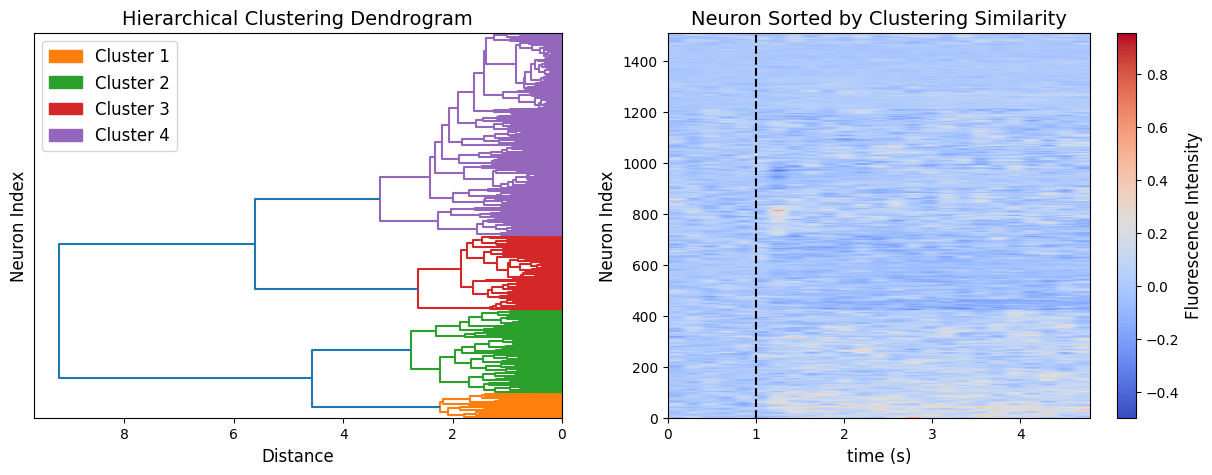

In [136]:
import lib.signalProcess as signalProcess
import lib.plotting as plotting

# Specify sound level to cluster
dB = 70
avg_traces_dB = dFFtraces[:, levelLabels.index(dB), :]

# Filter non_NaN traces
avg_traces_dB = avg_traces_dB[~np.isnan(avg_traces_dB).any(axis=1)]

# Calculate linkage matrix containing clustering distance
linkage_matrix = signalProcess.cluster_roi(avg_traces_dB)

# Plot hierarchical clustering dendrogram to visualize different clusters
print(f'Sound intensity: {dB} dB')
color_map, leaves_color_list, leaf_order = plotting.plot_hierarchical_cluster(linkage_matrix, avg_traces_dB, stimStart=1, 
                                                                              timeVector=timeVectors, Yaxis_label='Neuron', 
                                                                              color_threshold=0.5*max(linkage_matrix[:,2]), 
                                                                              # color_threshold=0.5, 
                                                                              n_clusters=4
)

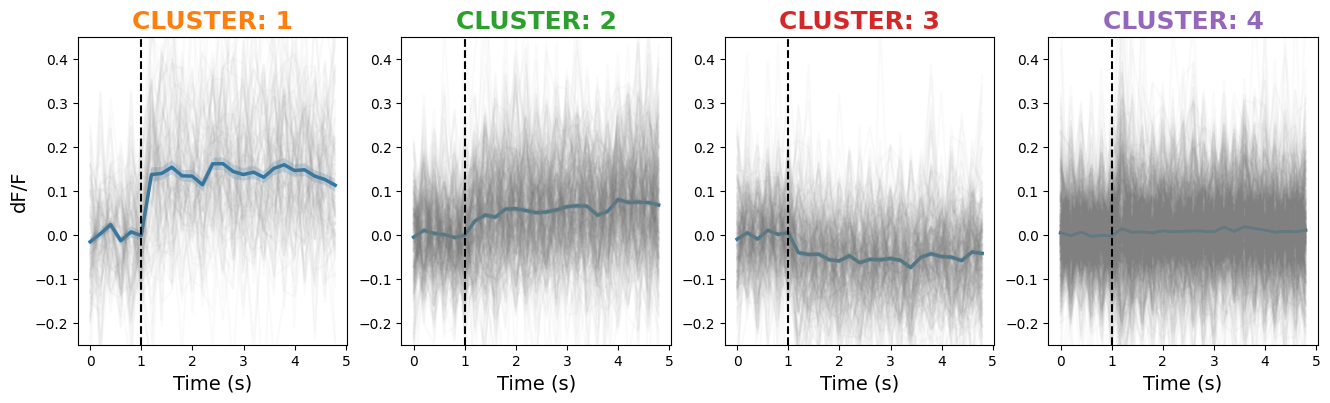

In [137]:
# Plot average fluorescence traces in each cluster

# Initialize a dictionary to store traces of each cluster
cluster_trace = {}
fig, ax = plt.subplots(1, len(color_map.keys()), figsize=(4*len(color_map.keys()), 4))

for i, (cluster_color, cluster_d) in enumerate(color_map.items()):
    cluster_name = f"CLUSTER: {cluster_d['cluster_id']}"

    # Fluorescence traces of all neurons for each cluster
    avg_traces_dB_cluster = avg_traces_dB[leaf_order[leaves_color_list==cluster_color]]

    # Add fluorescence traces into dictionary
    cluster_trace[cluster_name] = avg_traces_dB_cluster
    
    # Average fluorescence traces across neurons
    avg_traces_dB_cluster_avg, uFpsem, uFmsem = signalProcess.meanPlusMinusSem(avg_traces_dB_cluster)

    ax[i].plot(timeVectors, avg_traces_dB_cluster_avg, linewidth=2.5)
    # Plot individual traces of each neuron
    for trace in avg_traces_dB_cluster:
        ax[i].plot(timeVectors, trace, color='gray', alpha=0.04)
    # Plot error bars
    ax[i].fill_between(timeVectors, uFpsem, uFmsem, alpha=0.2)
    ax[i].set_xlabel('Time (s)', fontsize=14)
    ax[i].axvline(x=1, color='k', linestyle='--')
    ax[i].set_title(cluster_name, color=cluster_d['cluster_color'], fontsize=18, fontweight='bold')
    ax[i].set_ylim((-0.25, 0.45))

ax[0].set_ylabel('dF/F', fontsize=14)
plt.show()

## 6. Optionally visualize neuron indices in responsive clusters

In [498]:
# Initialize a dictionary to store neuron indices in the responsive cluster re sound level
# respCluster_neuron_index = {}
# respCluster_neuron_index[f'{dB}dB'] = np.sort(leaf_order[leaves_color_list == 'C1'])
# respCluster_neuron_index[f'{dB}dB'] = np.sort(leaf_order[(leaves_color_list == 'C1') | (leaves_color_list == 'C3')])

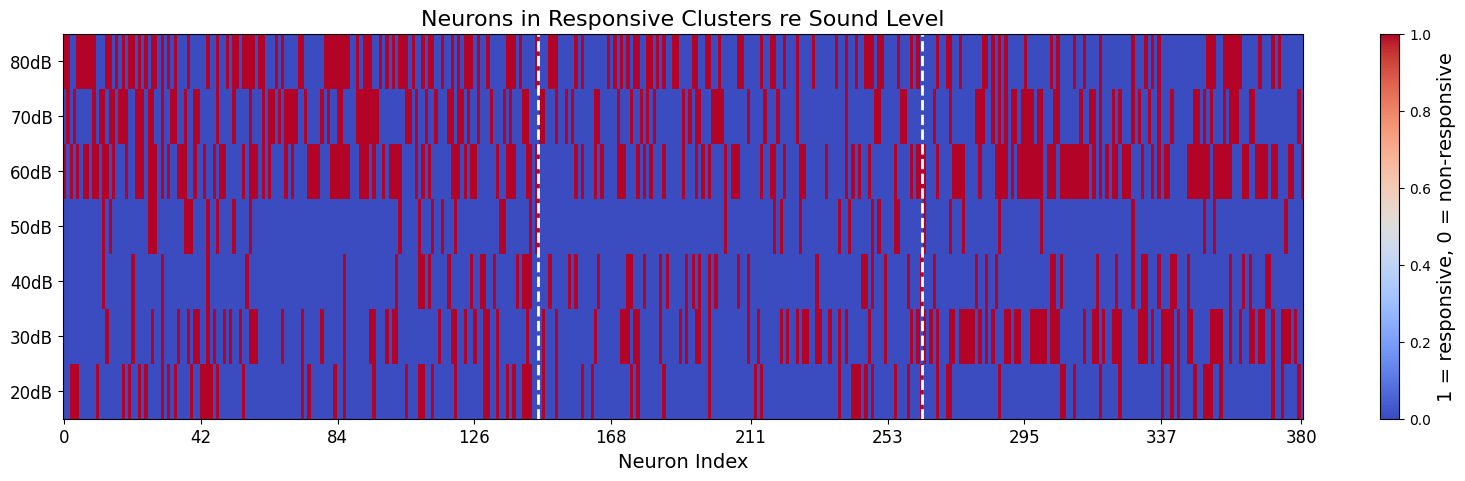

In [ ]:
# Plot neuron indices in responsive clusters across different sound levels

# Total number of neurons
n_neurons = avg_traces_dB.shape[0]

# Sort sound levels by numeric value in ascending order
levels_sorted = sorted(respCluster_neuron_index.keys(), key=lambda k: int(k.replace('dB', '')))

# Create binary matrix: rows = neurons, columns = sound levels
responsive_matrix = np.zeros((n_neurons, len(levels_sorted)))

# Fill matrix with 1 for responsive neurons
for col, level in enumerate(levels_sorted):
    responsive_neurons = respCluster_neuron_index[level]
    responsive_matrix[responsive_neurons, col] = 1  # mark as responsive

# Transpose the matrix to rotate the plot
responsive_matrix_T = responsive_matrix.T

# Plot
fig, ax = plt.subplots(figsize=(20, 5))
img = ax.imshow(
    responsive_matrix_T,
    aspect='auto',
    origin='lower',
    cmap='coolwarm',  # blue–red colormap
    interpolation='nearest'
)

# Axis labels and ticks
ax.set_xticks(np.linspace(0, n_neurons-1, 10).astype(int))
ax.set_xlabel('Neuron Index', fontsize=14)
ax.set_yticks(np.arange(len(levels_sorted)))
ax.set_yticklabels(levels_sorted, fontsize=12)
ax.set_title('Neurons in Responsive Clusters re Sound Level', fontsize=16)
ax.tick_params(axis='both', labelsize=12)

# Add vertical lines to separate neurons from each animal
ax.axvline(x=dFFtraces_temp[0].shape[0]-0.5, color='w', linestyle='--', linewidth=2)
ax.axvline(x=dFFtraces_temp[0].shape[0]+dFFtraces_temp[1].shape[0]-0.5, color='w', linestyle='--', linewidth=2)

# Colorbar
cbar = plt.colorbar(img, ax=ax)
cbar.set_label('1 = responsive, 0 = non-responsive', fontsize=14)

plt.show()

## 7. Hierarchical clustering (responsive neurons)

Input data shape for clustering: (244, 25)
Sound intensity: 40 dB


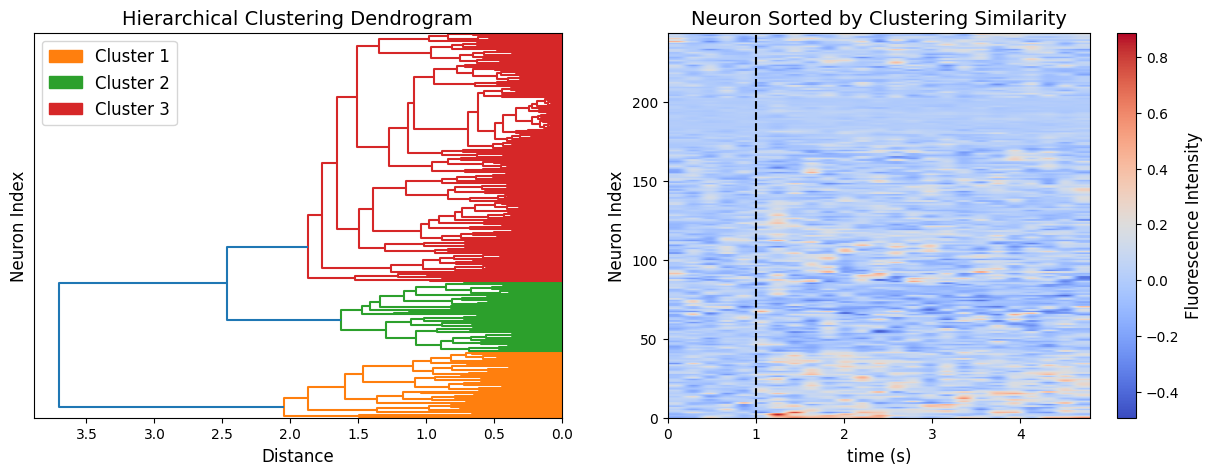

In [175]:
avg_traces_dB = dFFtraces[respIndices, levelLabels.index(dB), :]

# Filter non_NaN traces
avg_traces_dB = avg_traces_dB[~np.isnan(avg_traces_dB).any(axis=1)]

# Calculate linkage matrix containing clustering distance
linkage_matrix = signalProcess.cluster_roi(avg_traces_dB)

# Plot hierarchical clustering dendrogram to visualize different clusters
print(f'Sound intensity: {dB} dB')
color_map, leaves_color_list, leaf_order = plotting.plot_hierarchical_cluster(linkage_matrix, avg_traces_dB, stimStart=1, 
                                                                              timeVector=timeVectors, Yaxis_label='Neuron', 
                                                                              color_threshold=0.8*max(linkage_matrix[:,2]), 
                                                                              # color_threshold=0.5, 
                                                                              n_clusters=3
)

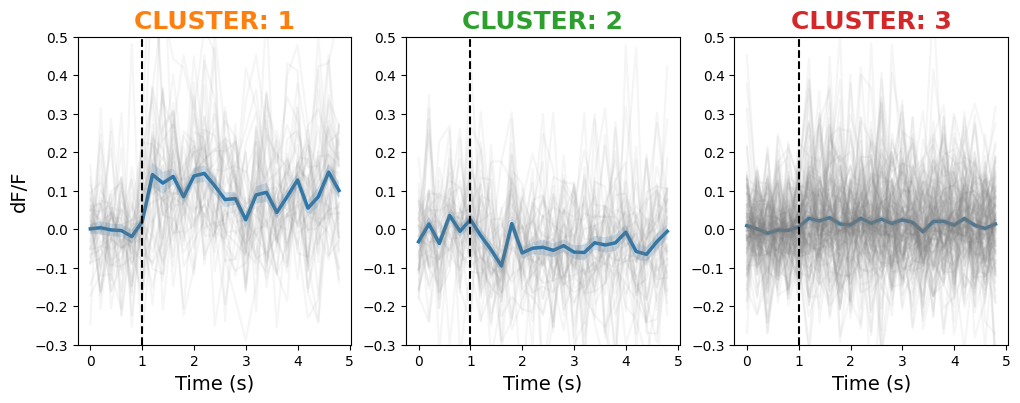

In [176]:
# Plot average fluorescence traces in each cluster

# Initialize a dictionary to store traces of each cluster
cluster_trace = {}
fig, ax = plt.subplots(1, len(color_map.keys()), figsize=(4*len(color_map.keys()), 4))

for i, (cluster_color, cluster_d) in enumerate(color_map.items()):
    cluster_name = f"CLUSTER: {cluster_d['cluster_id']}"

    # Fluorescence traces of all neurons for each cluster
    avg_traces_dB_cluster = avg_traces_dB[leaf_order[leaves_color_list==cluster_color]]

    # Add fluorescence traces into dictionary
    cluster_trace[cluster_name] = avg_traces_dB_cluster
    
    # Average fluorescence traces across neurons
    avg_traces_dB_cluster_avg, uFpsem, uFmsem = signalProcess.meanPlusMinusSem(avg_traces_dB_cluster)

    ax[i].plot(timeVectors, avg_traces_dB_cluster_avg, linewidth=2.5)
    # Plot individual traces of each neuron
    for trace in avg_traces_dB_cluster:
        ax[i].plot(timeVectors, trace, color='gray', alpha=0.08)
    # Plot error bars
    ax[i].fill_between(timeVectors, uFpsem, uFmsem, alpha=0.2)
    ax[i].set_xlabel('Time (s)', fontsize=14)
    ax[i].axvline(x=1, color='k', linestyle='--')
    ax[i].set_title(cluster_name, color=cluster_d['cluster_color'], fontsize=18, fontweight='bold')
    ax[i].set_ylim((-0.3, 0.5))

ax[0].set_ylabel('dF/F', fontsize=14)
plt.show()

## 8. Hierarchical clustering (0.3-1.3 sec after stim, all neurons)

Input data shape for clustering: (590, 5)
Sound intensity: 40 dB


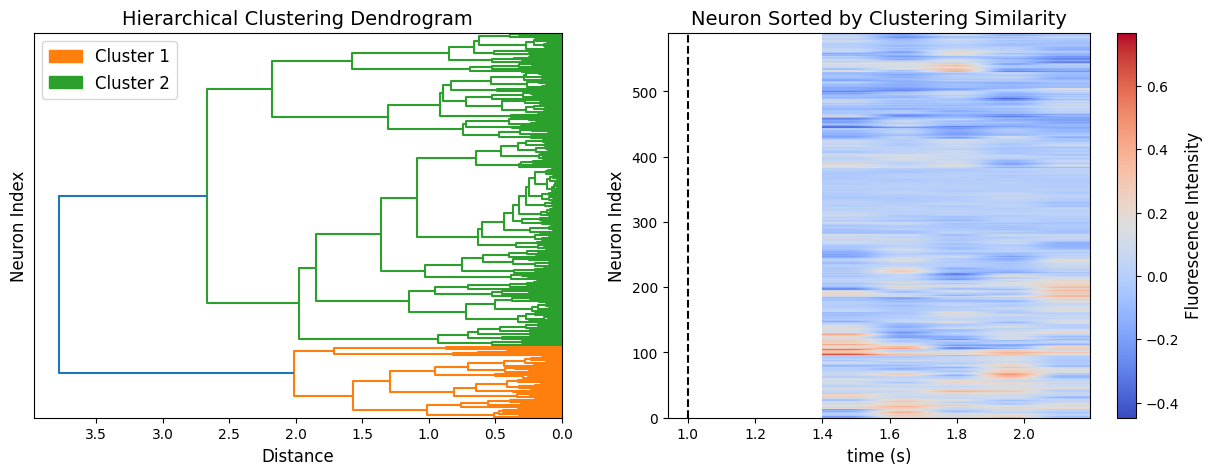

In [182]:
# Specify sound level to cluster
dB = 40
avg_traces_dB = dFFtraces[:, levelLabels.index(dB), :]
avg_traces_dB = avg_traces_dB[~np.isnan(avg_traces_dB).any(axis=1)]  # Filter non_NaN traces
avg_traces_dB_response = avg_traces_dB[:, np.where((timeVectors>=1.3) & (timeVectors<=2.3))[0]]

# Calculate linkage matrix containing clustering distance
linkage_matrix = signalProcess.cluster_roi(avg_traces_dB_response)

# Plot hierarchical clustering dendrogram to visualize different clusters
print(f'Sound intensity: {dB} dB')
color_map, leaves_color_list, leaf_order = plotting.plot_hierarchical_cluster(linkage_matrix, avg_traces_dB_response, stimStart=1, 
                                                                              timeVector=timeVectors[np.where((timeVectors>=1.3) & (timeVectors<=2.3))[0]], Yaxis_label='Neuron', 
                                                                              color_threshold=0.5*max(linkage_matrix[:,2]), 
                                                                              # color_threshold=0.5, 
                                                                              n_clusters=2
)

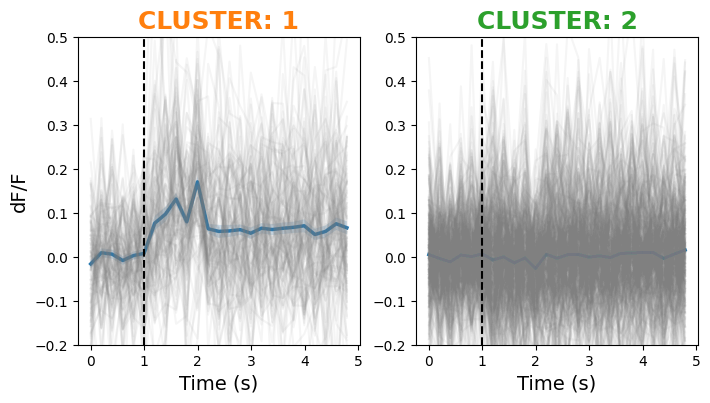

In [184]:
# Plot average fluorescence traces in each cluster

# Initialize a dictionary to store traces of each cluster
cluster_trace = {}
fig, ax = plt.subplots(1, len(color_map.keys()), figsize=(4*len(color_map.keys()), 4))

for i, (cluster_color, cluster_d) in enumerate(color_map.items()):
    cluster_name = f"CLUSTER: {cluster_d['cluster_id']}"

    # Fluorescence traces of all neurons for each cluster
    avg_traces_dB_cluster = avg_traces_dB[leaf_order[leaves_color_list==cluster_color]]

    # Add fluorescence traces into dictionary
    cluster_trace[cluster_name] = avg_traces_dB_cluster
    
    # Average fluorescence traces across neurons
    avg_traces_dB_cluster_avg, uFpsem, uFmsem = signalProcess.meanPlusMinusSem(avg_traces_dB_cluster)

    ax[i].plot(timeVectors, avg_traces_dB_cluster_avg, linewidth=2.5)
    # Plot individual traces of each neuron
    for trace in avg_traces_dB_cluster:
        ax[i].plot(timeVectors, trace, color='gray', alpha=0.08)
    # Plot error bars
    ax[i].fill_between(timeVectors, uFpsem, uFmsem, alpha=0.2)
    ax[i].set_xlabel('Time (s)', fontsize=14)
    ax[i].axvline(x=1, color='k', linestyle='--')
    ax[i].set_title(cluster_name, color=cluster_d['cluster_color'], fontsize=18, fontweight='bold')
    ax[i].set_ylim((-0.2, 0.5))

ax[0].set_ylabel('dF/F', fontsize=14)

plt.show()

## 9. Optionally visualize neuron indices in responsive clusters (0.3-1.3 sec after stim)

In [ ]:
# Initialize a dictionary to store neuron indices in the responsive cluster re sound level
# respCluster_neuron_response_index = {}
# respCluster_neuron_response_index[f'{dB}dB'] = np.sort(leaf_order[leaves_color_list == 'C2'])
# respCluster_neuron_response_index[f'{dB}dB'] = np.sort(leaf_order[(leaves_color_list == 'C1') | (leaves_color_list == 'C3')])
# respCluster_neuron_response_index

{'20dB': array([  4,   7,   9,  11,  16,  18,  20,  23,  30,  34,  36,  42,  43,
         47,  51,  52,  57,  73,  83,  92,  95, 109, 120, 121, 127, 129,
        143, 147, 194, 198, 201, 223, 238, 242, 243, 244, 246, 248, 263,
        268, 271, 272, 273, 275, 284, 289, 298, 300, 307, 308, 330, 350,
        351, 367, 371, 379]),
 '30dB': array([ 27,  33,  38,  41,  44,  46,  52,  57,  59, 115, 119, 122, 130,
        133, 136, 151, 175, 198, 208, 217, 225, 231, 232, 238, 247, 264,
        278, 281, 290, 293, 298, 301, 307, 313, 317, 331, 336, 337, 340,
        342, 345, 346, 354, 358, 364, 374, 375, 376]),
 '40dB': array([  4,   6,   8,   9,  12,  13,  15,  20,  21,  24,  29,  30,  33,
         34,  36,  39,  41,  44,  46,  49,  50,  51,  56,  57,  58,  60,
         61,  62,  65,  70,  72,  76,  79,  81,  86,  87,  90,  95,  98,
        102, 104, 107, 110, 111, 112, 113, 116, 122, 124, 126, 127, 128,
        129, 132, 133, 134, 135, 136, 137, 138, 139, 140, 142, 144, 145,
        148, 15

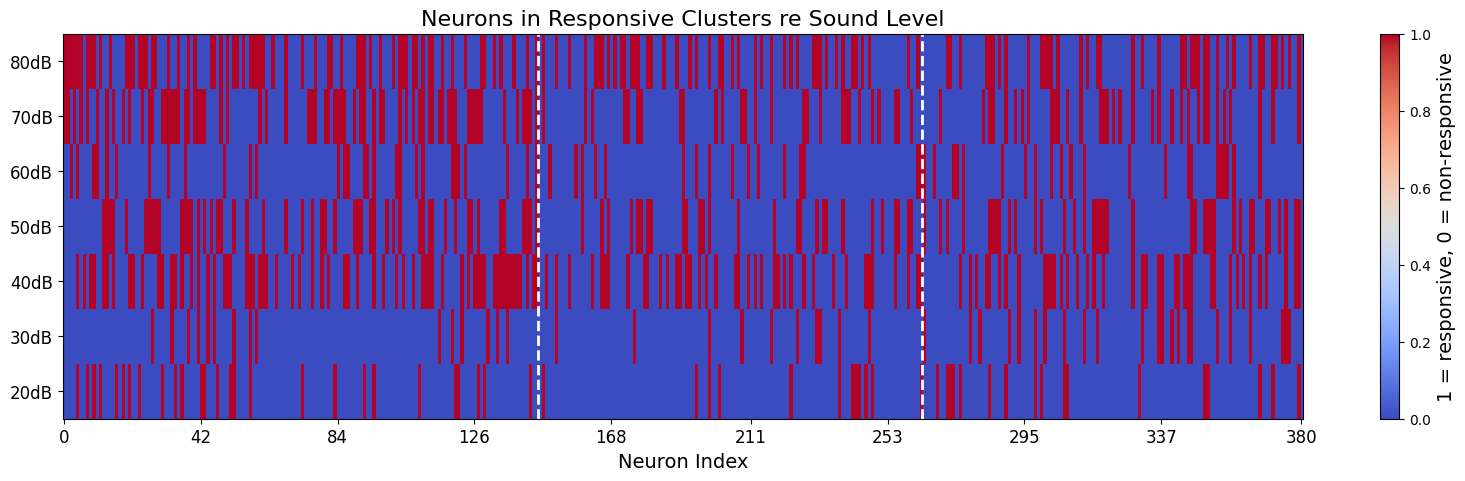

In [ ]:
# Plot neuron indices in responsive clusters across different sound levels

# Total number of neurons
n_neurons = avg_traces_dB.shape[0]

# Sort sound levels by numeric value in ascending order
levels_sorted = sorted(respCluster_neuron_response_index.keys(), key=lambda k: int(k.replace('dB', '')))

# Create binary matrix: rows = neurons, columns = sound levels
responsive_matrix = np.zeros((n_neurons, len(levels_sorted)))

# Fill matrix with 1 for responsive neurons
for col, level in enumerate(levels_sorted):
    responsive_neurons = respCluster_neuron_response_index[level]
    responsive_matrix[responsive_neurons, col] = 1  # mark as responsive

# Transpose the matrix to rotate the plot
responsive_matrix_T = responsive_matrix.T

# Plot
fig, ax = plt.subplots(figsize=(20, 5))
img = ax.imshow(
    responsive_matrix_T,
    aspect='auto',
    origin='lower',
    cmap='coolwarm',  # blue–red colormap
    interpolation='nearest'
)

# Axis labels and ticks
ax.set_xticks(np.linspace(0, n_neurons-1, 10).astype(int))
ax.set_xlabel('Neuron Index', fontsize=14)
ax.set_yticks(np.arange(len(levels_sorted)))
ax.set_yticklabels(levels_sorted, fontsize=12)
ax.set_title('Neurons in Responsive Clusters re Sound Level', fontsize=16)
ax.tick_params(axis='both', labelsize=12)

# Add vertical lines to separate neurons from each animal
ax.axvline(x=dFFtraces_temp[0].shape[0]-0.5, color='w', linestyle='--', linewidth=2)
ax.axvline(x=dFFtraces_temp[0].shape[0]+dFFtraces_temp[1].shape[0]-0.5, color='w', linestyle='--', linewidth=2)

# Colorbar
cbar = plt.colorbar(img, ax=ax)
cbar.set_label('1 = responsive, 0 = non-responsive', fontsize=14)

plt.show()

## 10. Correlation between baseline fluorescence and response amplitude re neuron